In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report
from IPython.display import display, HTML
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error, auc, roc_curve, roc_auc_score
from decimal import Decimal
import geopandas as gpd
from shapely.geometry import Point
from scipy.interpolate import griddata
import rasterio
from rasterio.transform import from_origin

# Get multiple outputs in the same cell
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# Ignore all warnings
import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings(action='ignore', category=DeprecationWarning)
pd.set_option('display.max_columns', None)

## Data preparation

In [2]:
# Read in the data 
# We have two dataframes with same column but different data 
# I believe we should have one dataframe contain information about both dataframes (presence and absence)

# Here I was reading in old data. Just want to show Kyle the difference between old and new data
# presence_df = pd.read_csv('C:/Users/charl/Desktop/__Thesis - Research/Github/vineyard-establishment-using-xgboost/points_data/points_of_presence_test_old.csv', delimiter=';')
# absence_df = pd.read_csv('C:/Users/charl/Desktop/__Thesis - Research/Github/vineyard-establishment-using-xgboost/points_data/points_of_absence_test_old.csv', delimiter=';')

presence_df = pd.read_csv('C:/Users/charl/Desktop/__Thesis - Research/Github/vineyard-establishment-using-xgboost/input_points_data/points_of_presence_test_new.csv', delimiter=';')
absence_df = pd.read_csv('C:/Users/charl/Desktop/__Thesis - Research/Github/vineyard-establishment-using-xgboost/input_points_data/points_of_absence_test_new.csv', delimiter=';')

print("Presence info", presence_df.shape)
print("Absence info", absence_df.shape)

Presence info (46110, 26)
Absence info (46110, 26)


In [3]:
# Head for points of presence data
print("Points of presence")
presence_df.head()

# Head for points of absence data
print("Points of absence")
absence_df.head()

Points of presence


,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_slope_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_k30_wc,composite_temp_min_1000m_k30_wc,composite_temp_max_1000m_k30_wc,composite_rainfall_sum_1000m_k30_wc,composite_gdd_grapes_1000m_wc,composite_AETI_1000m_albers_wc,nitrogen_0_to_5cm_1000m_albers_wc,sand_0_to_5cm_1000m_albers_wc,soc_0_to_5cm_1000m_albers_wc,clay_content_0_to_5cm_1000m_albers_wc,soil_ph_0_to_5cm_1000m_albers_wc,silt_0_to_5cm_1000m_albers_wc,ndvi_wc,euclidean_distance_roads_1000m_albers_wc,euclidean_distance_rivers_1000m_albers_wc
0,1,"19,552906066300000","-33,503039127100003","423,8035889","1262675,2500000","7,6203117","11,7305155","21,6820641","155,2328949","294957,0312500","0,1973951","15,9867964","9,6832962","23,0573425","204,5053253","1866,6802979","9051,3925781","262,1053772","754,4794922","579,4953003","122,6880951","67,2119293","123,3386612","0,3997020","0,0000000","0,0000000"
1,2,"19,554065257300000","-33,502591599200002","418,8850098","1238057,0000000","7,5433488","13,2344179","24,5836411","151,8608856","295034,0312500","0,1286995","15,8695059","9,6180811","22,8775139","206,5435181","1837,9093018","9064,5273438","255,0745544","753,3905029","596,1103516","122,8667297","67,3483429","124,2754517","0,4077038","0,0000000","0,0000000"
2,3,"19,553220609499999","-33,504088723999999","408,7989197","1293872,6250000","7,6285295","9,4727755","17,4985867","153,0930939","294792,1250000","0,1446818","16,0426788","9,7182827","23,1365280","204,9259338","1879,4543457","9633,4052734","271,9782715","760,3276978","598,3022461","121,0519714","66,8941498","119,2392654","0,4207691","0,0000000","0,0000000"
3,4,"19,554527855100002","-33,504862308200003","393,0697327","1312602,2500000","7,5401411","7,9924750","14,8219433","147,5858154","294676,7812500","0,0504019","16,0228729","9,7115231","23,0989895","207,0958252","1873,5273438","10316,7373047","279,1886597","766,2723389","630,4938965","119,1085968","66,6778259","115,3868942","0,4456471","0,0000000","0,0000000"
4,5,"19,553802071600000","-33,504471387300001","400,9482727","1303012,5000000","7,5930171","8,7492332","16,1888485","150,6344604","294734,6562500","0,0999071","16,0353279","9,7162180","23,1218605","205,8853760","1877,1494141","9953,2421875","275,1390381","763,1566162","614,1897583","120,1982269","66,7786255","117,3420486","0,4328750","0,0000000","0,0000000"


Points of absence


,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_slope_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_k30_wc,composite_temp_min_1000m_k30_wc,composite_temp_max_1000m_k30_wc,composite_rainfall_sum_1000m_k30_wc,composite_gdd_grapes_1000m_wc,composite_AETI_1000m_albers_wc,nitrogen_0_to_5cm_1000m_albers_wc,sand_0_to_5cm_1000m_albers_wc,soc_0_to_5cm_1000m_albers_wc,clay_content_0_to_5cm_1000m_albers_wc,soil_ph_0_to_5cm_1000m_albers_wc,silt_0_to_5cm_1000m_albers_wc,ndvi_wc,euclidean_distance_roads_1000m_albers_wc,euclidean_distance_rivers_1000m_albers_wc
0,1,"21,568219575073385","-32,845436310137586","667,1586914","1483005,1250000","9,0135527","2,1335182","3,4945560","134,8665924","297321,6562500","-0,0866669","18,6504345","11,5633831","26,4917850","40,3150101","2625,9384766","1005,2607422","52,6314621","693,5087891","46,7836609","138,2878418","74,7023392","168,2033691","0,0878413","0,0240000","0,0480000"
1,2,"19,929761337216007","-34,669140494937835","17,7988892","1334560,0000000","8,8747396","1,1062130","1,7273655","152,5726471","27658,9550781","-0,0117142","18,1583271","13,7313309","23,9642906","231,7956696","2157,1762695","4419,1899414","245,2176666","639,4815674","445,3425293","193,3942566","69,1715851","167,1241913","0,2856699","0,0037139","0,0037139"
2,3,"20,853933888937888","-33,715715851505308","487,1492310","1444049,5000000","7,2310748","2,3288376","4,0689297","131,4290314","225323,4218750","-0,0191663","17,1582813","10,4304876","25,2325687","118,7681351","2206,4777832","1042,4602051","178,8755035","651,9295044","232,8902435","191,7061310","77,0000000","156,5092010","0,1098227","0,0339411","0,0480000"
3,4,"19,913425410354478","-33,069432348823796","595,4059448","1477565,2500000","8,2927780","1,5052947","2,0903606","157,0732117","388392,0000000","-0,0615444","17,6923790","10,1807861","26,0774708","39,0124130","2364,7324219","1129,3968506","68,1352386","713,8799438","87,1456985","150,1565552","80,7177124","135,9635010","0,1504509","0,0291952","0,0000000"
4,5,"21,591854189219532","-32,879877811112067","677,4995728","1508521,2500000","7,9686489","2,6092782","4,5575848","294,1683960","296658,8750000","0,0365601","18,5143147","11,5140390","26,2532215","39,0649796","2588,6350098","997,8342285","49,6851540","705,8392944","27,6697407","126,7174072","73,2194366","167,4905548","0,0906056","0,0008665","0,0378356"


In [4]:
# Describe the data
print("Points of presence description")
presence_df.describe()

# I think the other columns are not included due to data type being object
print("Points of absence description")
absence_df.describe()

Points of presence description


,OID_
count,46110.000000
mean,23055.500000
std,13310.954793
min,1.000000
25%,11528.250000
50%,23055.500000
75%,34582.750000
max,46110.000000


Points of absence description


,OID_
count,46110.000000
mean,23055.500000
std,13310.954793
min,1.000000
25%,11528.250000
50%,23055.500000
75%,34582.750000
max,46110.000000


In [5]:
# Check for Null values 
print("Null result for presence")
presence_df.isnull().sum()

print("Null results for absence")
absence_df.isnull().sum()

Null result for presence


OID_                                              0
POINT_X                                           0
POINT_Y                                           0
sudem_1000m_albers_filled_wc                      0
sudem_1000m_albers_potential_solar_rad_wh2m_wc    0
sudem_1000m_albers_twi_d8_wc                      0
sudem_1000m_albers_slope_degree_wc                0
sudem_1000m_albers_slope_wc                       0
sudem_1000m_albers_aspect_wc                      0
sudem_1000m_albers_flow_network_wc                2
sudem_1000m_albers_curvature_wc                   2
composite_temp_mean_1000m_k30_wc                  4
composite_temp_min_1000m_k30_wc                   4
composite_temp_max_1000m_k30_wc                   4
composite_rainfall_sum_1000m_k30_wc               2
composite_gdd_grapes_1000m_wc                     4
composite_AETI_1000m_albers_wc                    0
nitrogen_0_to_5cm_1000m_albers_wc                 0
sand_0_to_5cm_1000m_albers_wc                     0
soc_0_to_5cm

Null results for absence


OID_                                              0
POINT_X                                           0
POINT_Y                                           0
sudem_1000m_albers_filled_wc                      0
sudem_1000m_albers_potential_solar_rad_wh2m_wc    0
sudem_1000m_albers_twi_d8_wc                      0
sudem_1000m_albers_slope_degree_wc                0
sudem_1000m_albers_slope_wc                       0
sudem_1000m_albers_aspect_wc                      0
sudem_1000m_albers_flow_network_wc                0
sudem_1000m_albers_curvature_wc                   0
composite_temp_mean_1000m_k30_wc                  1
composite_temp_min_1000m_k30_wc                   1
composite_temp_max_1000m_k30_wc                   1
composite_rainfall_sum_1000m_k30_wc               0
composite_gdd_grapes_1000m_wc                     1
composite_AETI_1000m_albers_wc                    2
nitrogen_0_to_5cm_1000m_albers_wc                 0
sand_0_to_5cm_1000m_albers_wc                     0
soc_0_to_5cm

In [6]:
# Adding suitability column to both df and assigning a value of 1 to where there vineyards and 0 where there are no vineyards

presence_df['suitability'] = 1  # Highly suitable (characteristics for suitable vineyards)
absence_df['suitability'] = 0  # Less suitable (characteristics for potential suitability/ non suitability)

# Checking size of the dataframes
print("Checking size of the dataframes")
presence_df['suitability'].value_counts()
absence_df['suitability'].value_counts()

Checking size of the dataframes


suitability
1    46110
Name: count, dtype: int64

suitability
0    46110
Name: count, dtype: int64

In [7]:
# Combine the datasets
# other combining functions include merge() join()
# combined_df = pd.concat([presence_df, absence_df], axis=0) (This concatinates my df as strings which resulted in some values being Nan, results in twice as many points)

# merge function combines the df using a common column and then renames columns that were same using x o y suffixes 
# results in 46110 points (original value)
# creates separate column called suitability_x and suitability_y 
# concatinating the df vertically and axis=0 adds rows, axis = 1 adds columns

combined_df = pd.concat([presence_df, absence_df], axis=0, ignore_index=True)

print("combined dataframe")
combined_df


combined dataframe


,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_slope_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_k30_wc,composite_temp_min_1000m_k30_wc,composite_temp_max_1000m_k30_wc,composite_rainfall_sum_1000m_k30_wc,composite_gdd_grapes_1000m_wc,composite_AETI_1000m_albers_wc,nitrogen_0_to_5cm_1000m_albers_wc,sand_0_to_5cm_1000m_albers_wc,soc_0_to_5cm_1000m_albers_wc,clay_content_0_to_5cm_1000m_albers_wc,soil_ph_0_to_5cm_1000m_albers_wc,silt_0_to_5cm_1000m_albers_wc,ndvi_wc,euclidean_distance_roads_1000m_albers_wc,euclidean_distance_rivers_1000m_albers_wc,suitability
0,1,"19,552906066300000","-33,503039127100003","423,8035889","1262675,2500000","7,6203117","11,7305155","21,6820641","155,2328949","294957,0312500","0,1973951","15,9867964","9,6832962","23,0573425","204,5053253","1866,6802979","9051,3925781","262,1053772","754,4794922","579,4953003","122,6880951","67,2119293","123,3386612","0,3997020","0,0000000","0,0000000",1
1,2,"19,554065257300000","-33,502591599200002","418,8850098","1238057,0000000","7,5433488","13,2344179","24,5836411","151,8608856","295034,0312500","0,1286995","15,8695059","9,6180811","22,8775139","206,5435181","1837,9093018","9064,5273438","255,0745544","753,3905029","596,1103516","122,8667297","67,3483429","124,2754517","0,4077038","0,0000000","0,0000000",1
2,3,"19,553220609499999","-33,504088723999999","408,7989197","1293872,6250000","7,6285295","9,4727755","17,4985867","153,0930939","294792,1250000","0,1446818","16,0426788","9,7182827","23,1365280","204,9259338","1879,4543457","9633,4052734","271,9782715","760,3276978","598,3022461","121,0519714","66,8941498","119,2392654","0,4207691","0,0000000","0,0000000",1
3,4,"19,554527855100002","-33,504862308200003","393,0697327","1312602,2500000","7,5401411","7,9924750","14,8219433","147,5858154","294676,7812500","0,0504019","16,0228729","9,7115231","23,0989895","207,0958252","1873,5273438","10316,7373047","279,1886597","766,2723389","630,4938965","119,1085968","66,6778259","115,3868942","0,4456471","0,0000000","0,0000000",1
4,5,"19,553802071600000","-33,504471387300001","400,9482727","1303012,5000000","7,5930171","8,7492332","16,1888485","150,6344604","294734,6562500","0,0999071","16,0353279","9,7162180","23,1218605","205,8853760","1877,1494141","9953,2421875","275,1390381","763,1566162","614,1897583","120,1982269","66,7786255","117,3420486","0,4328750","0,0000000","0,0000000",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92215,46106,"23,495416236370261","-31,793901584990124","1162,4739990","1597666,8750000","9,1995277","1,0253339","0,8319384","133,0602570","411619,1250000","-0,0163932","16,7675591","9,2552242","24,7319012","154,0359039","2195,5539551","1137,9976807","63,1911736","599,7850342","71,1006393","203,1139832","80,7703247","197,1394501","0,1382415","0,0000000","0,0480000",0
92216,46107,"22,715602905349840","-31,872963273935909","1323,8831787","1618685,0000000","9,0564175","0,4957476","0,8652785","115,7642212","452081,5625000","0,0332791","16,4653759","10,1061459","23,1868896","73,6929855","2037,0895996","1219,7507324","67,8278656","607,3751831","68,1308975","183,7181549","78,4343643","208,9066467","0,1322167","0,0034267","0,0034267",0
92217,46108,"22,474740777764737","-31,765556181672423","1554,3348389","1665689,3750000","7,5474143","1,6631688","2,9036171","149,8292694","478055,4375000","-0,0227279","15,5771427","9,6843328","21,7293301","53,4433708","1825,0356445","1559,5961914","73,2299728","597,6461792","62,1008034","180,7212372","77,8456345","221,6186066","0,1539931","0,0453529","0,0138854",0
92218,46109,"23,662031286414788","-31,911282061617783","1131,0124512","1599360,2500000","8,4490862","1,8949413","3,2963638","337,2799683","397868,5312500","0,0661309","16,7568569","8,8685846","

In [8]:
# Data types of the columns before conversion
combined_df.dtypes

OID_                                               int64
POINT_X                                           object
POINT_Y                                           object
sudem_1000m_albers_filled_wc                      object
sudem_1000m_albers_potential_solar_rad_wh2m_wc    object
sudem_1000m_albers_twi_d8_wc                      object
sudem_1000m_albers_slope_degree_wc                object
sudem_1000m_albers_slope_wc                       object
sudem_1000m_albers_aspect_wc                      object
sudem_1000m_albers_flow_network_wc                object
sudem_1000m_albers_curvature_wc                   object
composite_temp_mean_1000m_k30_wc                  object
composite_temp_min_1000m_k30_wc                   object
composite_temp_max_1000m_k30_wc                   object
composite_rainfall_sum_1000m_k30_wc               object
composite_gdd_grapes_1000m_wc                     object
composite_AETI_1000m_albers_wc                    object
nitrogen_0_to_5cm_1000m_albers_

In [9]:
# Remove commas from the values and convert to float/double
def clean_and_convert(x):
    return x.str.replace(',', '.').astype('float')

columns_to_convert = ['POINT_X', 'POINT_Y', 'sudem_1000m_albers_filled_wc', 'sudem_1000m_albers_potential_solar_rad_wh2m_wc',
                        'sudem_1000m_albers_twi_d8_wc', 'sudem_1000m_albers_slope_degree_wc', 'sudem_1000m_albers_slope_wc',
                        'sudem_1000m_albers_aspect_wc', 'sudem_1000m_albers_flow_network_wc', 'sudem_1000m_albers_curvature_wc',
                        'composite_temp_mean_1000m_k30_wc', 'composite_temp_min_1000m_k30_wc', 'composite_temp_max_1000m_k30_wc',
                        'composite_rainfall_sum_1000m_k30_wc', 'composite_gdd_grapes_1000m_wc', 'composite_AETI_1000m_albers_wc',
                        'nitrogen_0_to_5cm_1000m_albers_wc', 'sand_0_to_5cm_1000m_albers_wc', 'soc_0_to_5cm_1000m_albers_wc',
                        'clay_content_0_to_5cm_1000m_albers_wc', 'soil_ph_0_to_5cm_1000m_albers_wc', 'silt_0_to_5cm_1000m_albers_wc',
                        'ndvi_wc', 'euclidean_distance_roads_1000m_albers_wc', 'euclidean_distance_rivers_1000m_albers_wc'] # Add all relevant columns
for col in columns_to_convert:
    combined_df[col] = clean_and_convert(combined_df[col])

In [10]:
# Data types of the columns after conversion
combined_df.dtypes

OID_                                                int64
POINT_X                                           float64
POINT_Y                                           float64
sudem_1000m_albers_filled_wc                      float64
sudem_1000m_albers_potential_solar_rad_wh2m_wc    float64
sudem_1000m_albers_twi_d8_wc                      float64
sudem_1000m_albers_slope_degree_wc                float64
sudem_1000m_albers_slope_wc                       float64
sudem_1000m_albers_aspect_wc                      float64
sudem_1000m_albers_flow_network_wc                float64
sudem_1000m_albers_curvature_wc                   float64
composite_temp_mean_1000m_k30_wc                  float64
composite_temp_min_1000m_k30_wc                   float64
composite_temp_max_1000m_k30_wc                   float64
composite_rainfall_sum_1000m_k30_wc               float64
composite_gdd_grapes_1000m_wc                     float64
composite_AETI_1000m_albers_wc                    float64
nitrogen_0_to_

In [11]:
# Describe the data and check for nulls again

combined_df.describe()
combined_df.head(10)
combined_df['suitability'].value_counts()

,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_slope_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_k30_wc,composite_temp_min_1000m_k30_wc,composite_temp_max_1000m_k30_wc,composite_rainfall_sum_1000m_k30_wc,composite_gdd_grapes_1000m_wc,composite_AETI_1000m_albers_wc,nitrogen_0_to_5cm_1000m_albers_wc,sand_0_to_5cm_1000m_albers_wc,soc_0_to_5cm_1000m_albers_wc,clay_content_0_to_5cm_1000m_albers_wc,soil_ph_0_to_5cm_1000m_albers_wc,silt_0_to_5cm_1000m_albers_wc,ndvi_wc,euclidean_distance_roads_1000m_albers_wc,euclidean_distance_rivers_1000m_albers_wc,suitability
count,92220.000000,92220.000000,92220.000000,92220.000000,9.222000e+04,92220.000000,92220.000000,92220.000000,92220.000000,92218.000000,92218.000000,92215.000000,92215.000000,92215.000000,92218.000000,92215.000000,92218.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92219.000000,92220.000000,92220.000000,92220.000000
mean,23055.500000,19.911518,-33.252359,410.186418,1.418921e+06,8.022344,5.848445,10.526389,183.956392,195589.543491,0.001042,17.253188,11.406758,24.188069,227.269529,2149.435938,4743.151560,208.959731,715.950744,336.835294,139.967260,67.839283,125.306119,0.302482,0.007094,0.020921,0.500000
std,13310.882622,1.435040,0.826937,360.676613,8.119734e+04,1.695695,6.348223,12.483488,73.886220,119431.143639,0.166475,1.175132,1.230188,1.721300,176.797435,278.469884,2511.117743,90.747868,103.970420,167.889763,43.894107,9.280704,41.279775,0.121426,0.016151,0.039905,0.500003
min,1.000000,17.842223,-34.791018,0.799565,7.840468e+05,2.934461,0.014561,0.000000,1.825276,756.470093,-3.864582,10.221187,5.271195,14.986521,19.185396,619.879334,208.368652,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.490443,0.000000,0.000000,0.000000
25%,11528.000000,18.855983,-33.834191,159.926044,1.377091e+06,7.006381,1.791921,2.958823,129.001457,75449.628906,-0.052711,16.741623,10.697241,23.194470,93.026997,2011.494324,2678.495728,129.124641,662.437058,204.204910,104.861471,63.268241,94.866283,0.194718,0.000000,0.000000,0.000000
50%,23055.500000,19.347553,-33.558733,258.975861,1.400370e+06,7.782132,3.464592,5.995954,185.871468,209083.507812,-0.001051,17.378757,11.513188,24.464731,175.376473,2189.730225,4762.085938,227.240799,729.614655,351.578049,132.793838,67.554493,125.713940,0.315257,0.000000,0.000000,0.500000
75%,34583.000000,20.660675,-32.815619,597.993195,1.456098e+06,8.706856,7.371059,13.003455,240.100498,288047.617188,0.050114,17.974816,12.479805,25.308208,305.785057,2318.544434,6680.186523,276.138100,790.963394,464.928406,174.714436,74.478222,152.361034,0.397390,0.000000,0.024000,1.000000
max,46110.000000,24.163170,-30.459279,2139.788330,1.842116e+06,25.779661,57.476253,159.018570,358.531403,501485.750000,4.648477,19.867142,13.864833,28.243813,2071.323242,2853.351318,13430.311523,502.066894,878.233643,1075.480835,313.768738,87.000000,345.055420,0.684458,0.160997,0.546844,1.000000


,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_slope_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_k30_wc,composite_temp_min_1000m_k30_wc,composite_temp_max_1000m_k30_wc,composite_rainfall_sum_1000m_k30_wc,composite_gdd_grapes_1000m_wc,composite_AETI_1000m_albers_wc,nitrogen_0_to_5cm_1000m_albers_wc,sand_0_to_5cm_1000m_albers_wc,soc_0_to_5cm_1000m_albers_wc,clay_content_0_to_5cm_1000m_albers_wc,soil_ph_0_to_5cm_1000m_albers_wc,silt_0_to_5cm_1000m_albers_wc,ndvi_wc,euclidean_distance_roads_1000m_albers_wc,euclidean_distance_rivers_1000m_albers_wc,suitability
0,1,19.552906,-33.503039,423.803589,1262675.250,7.620312,11.730515,21.682064,155.232895,294957.03125,0.197395,15.986796,9.683296,23.057343,204.505325,1866.680298,9051.392578,262.105377,754.479492,579.495300,122.688095,67.211929,123.338661,0.399702,0.0,0.0,1
1,2,19.554065,-33.502592,418.885010,1238057.000,7.543349,13.234418,24.583641,151.860886,295034.03125,0.128699,15.869506,9.618081,22.877514,206.543518,1837.909302,9064.527344,255.074554,753.390503,596.110352,122.866730,67.348343,124.275452,0.407704,0.0,0.0,1
2,3,19.553221,-33.504089,408.798920,1293872.625,7.628529,9.472775,17.498587,153.093094,294792.12500,0.144682,16.042679,9.718283,23.136528,204.925934,1879.454346,9633.405273,271.978272,760.327698,598.302246,121.051971,66.894150,119.239265,0.420769,0.0,0.0,1
3,4,19.554528,-33.504862,393.069733,1312602.250,7.540141,7.992475,14.821943,147.585815,294676.78125,0.050402,16.022873,9.711523,23.098989,207.095825,1873.527344,10316.737305,279.188660,766.272339,630.493897,119.108597,66.677826,115.386894,0.445647,0.0,0.0,1
4,5,19.553802,-33.504471,400.948273,1303012.500,7.593017,8.749233,16.188848,150.634460,294734.65625,0.099907,16.035328,9.716218,23.121861,205.885376,1877.149414,9953.242188,275.139038,763.156616,614.189758,120.198227,66.778626,117.342049,0.432875,0.0,0.0,1
5,6,19.555387,-33.504336,392.955597,1292736.500,7.469448,9.480661,17.662088,145.194199,294786.84375,0.018448,15.964849,9.677381,23.012052,208.632416,1859.454102,10222.166016,277.202332,764.602356,626.246460,118.700783,66.914009,117.348511,0.447238,0.0,0.0,1
6,7,19.548674,-33.503508,449.279846,1308277.000,7.915151,9.233222,16.703707,169.234070,294859.84375,0.454594,16.306629,9.857261,23.554279,196.491745,1946.126465,8380.437500,273.988556,751.666687,504.111237,123.961166,67.066811,124.641251,0.358081,0.0,0.0,1
7,8,19.549515,-33.503636,440.737823,1305373.500,7.868427,9.277800,16.855751,166.291809,294844.00000,0.393379,16.256386,9.830835,23.474735,198.115662,1933.438599,8615.666016,273.540253,753.282532,521.708069,123.427902,67.028778,123.620354,0.370797,0.0,0.0,1
8,9,19.549939,-33.504295,426.096741,1319490.125,7.883454,8.135272,14.778790,164.446976,294741.15625,0.330645,16.263691,9.837664,23.481428,198.865280,1934.607544,9001.917969,278.152191,756.843994,537.577454,122.441338,66.829239,121.110359,0.390278,0.0,0.0,1
9,10,19.551405,-33.503575,428.107666,1290336.875,7.737020,10.027763,18.395227,159.845047,294863.90625,0.276328,16.126350,9.760755,23.271597,201.806274,1900.974365,8992.549805,269.891998,755.372437,557.233521,122.625633,67.048576,122.454849,0.391179,0.0,0.0,1


suitability
1    46110
0    46110
Name: count, dtype: int64

In [12]:
# check for null in the combined_df
combined_df.isnull().sum()

OID_                                              0
POINT_X                                           0
POINT_Y                                           0
sudem_1000m_albers_filled_wc                      0
sudem_1000m_albers_potential_solar_rad_wh2m_wc    0
sudem_1000m_albers_twi_d8_wc                      0
sudem_1000m_albers_slope_degree_wc                0
sudem_1000m_albers_slope_wc                       0
sudem_1000m_albers_aspect_wc                      0
sudem_1000m_albers_flow_network_wc                2
sudem_1000m_albers_curvature_wc                   2
composite_temp_mean_1000m_k30_wc                  5
composite_temp_min_1000m_k30_wc                   5
composite_temp_max_1000m_k30_wc                   5
composite_rainfall_sum_1000m_k30_wc               2
composite_gdd_grapes_1000m_wc                     5
composite_AETI_1000m_albers_wc                    2
nitrogen_0_to_5cm_1000m_albers_wc                 0
sand_0_to_5cm_1000m_albers_wc                     0
soc_0_to_5cm

In [13]:
# sort the dataframes by POINT_X and POINT_Y
combined_df = combined_df.sort_values(by=['POINT_X', 'POINT_Y'])

In [14]:
combined_df

,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_slope_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_k30_wc,composite_temp_min_1000m_k30_wc,composite_temp_max_1000m_k30_wc,composite_rainfall_sum_1000m_k30_wc,composite_gdd_grapes_1000m_wc,composite_AETI_1000m_albers_wc,nitrogen_0_to_5cm_1000m_albers_wc,sand_0_to_5cm_1000m_albers_wc,soc_0_to_5cm_1000m_albers_wc,clay_content_0_to_5cm_1000m_albers_wc,soil_ph_0_to_5cm_1000m_albers_wc,silt_0_to_5cm_1000m_albers_wc,ndvi_wc,euclidean_distance_roads_1000m_albers_wc,euclidean_distance_rivers_1000m_albers_wc,suitability
88805,42696,17.842223,-31.092680,172.032547,1446455.000,8.559930,1.332115,2.302083,282.782105,12579.391602,-0.039437,18.211512,13.086869,24.443161,23.492949,2150.921875,1088.019898,95.183228,763.351868,231.830765,131.982803,75.000000,104.665314,0.187717,0.084747,0.099944,0
89145,43036,17.847598,-31.142158,121.793091,1437265.000,11.516044,0.510896,0.891735,260.428497,9141.754883,-0.010545,18.324986,13.154163,24.616901,24.394709,2177.283691,818.780823,99.691078,739.801636,245.586182,135.382660,77.091911,124.781982,0.178519,0.063441,0.058107,0
88892,42783,17.848675,-31.192200,82.575783,1427648.750,9.944447,1.111513,1.940225,250.937820,4899.702148,-0.016449,18.352282,13.179053,24.644382,25.483866,2181.080078,1083.154053,114.760010,738.753418,198.292496,133.001511,76.958816,128.421616,0.206206,0.024000,0.028478,0
90269,44160,17.856287,-31.134076,139.282974,1437422.500,10.066491,1.445921,2.524232,241.154190,10683.605469,0.072123,18.284254,13.123871,24.563217,24.477837,2168.239502,732.360168,100.003105,719.665283,238.487915,161.453735,77.569092,118.100815,0.179493,0.070676,0.058622,0
89928,43819,17.861519,-31.208286,111.086571,1429745.500,8.968467,1.739554,3.035772,229.335846,6184.509766,0.053375,18.301386,13.147077,24.567514,26.253515,2167.834961,1492.649048,118.835258,733.534302,195.166275,136.728302,76.470863,129.983551,0.212459,0.000000,0.024000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85674,39565,24.141927,-31.977841,1693.106201,1685273.875,6.826403,7.745956,13.632985,83.079071,288086.593750,-0.065672,13.785381,7.649215,20.238836,189.760086,1477.586426,3446.857666,149.797653,545.025818,156.837433,224.241119,72.482155,230.733093,0.191188,0.007489,0.030839,0
85333,39224,24.142348,-31.971373,1637.564453,1758190.375,7.920777,10.911353,19.280811,11.736856,170854.031250,-0.151414,13.774164,7.640666,20.223969,189.874374,1475.689819,3410.915039,143.322525,542.705627,147.901474,225.660584,73.127831,231.633774,0.201240,0.006464,0.034063,0
86102,39993,24.149071,-31.981486,1621.015747,1655597.375,8.528321,2.376466,4.139143,112.903915,221581.875000,0.018215,14.048969,7.808098,20.635817,187.915100,1539.027832,3685.477539,150.239044,548.953552,225.520065,227.819275,73.660194,223.227158,0.217607,0.000000,0.033941,0
92069,45960,24.162493,-31.932255,1527.335571,1685165.875,6.792073,1.623480,2.834443,48.230461,165712.718750,0.025140,14.598185,8.110333,21.492310,189.604981,1674.374878,2808.190918,118.419663,518.034790,105.113350,231.318726,73.000000,249.845581,0.202076,0.024000,0.084260,0


In [15]:
# Try to use interpolation to fill the null values after converting the columns to float
# Interpolation is done based on the surrounding values in the column
# add the columns that have null values to the list below

columns_to_interpolate = ['sudem_1000m_albers_curvature_wc', 'sudem_1000m_albers_flow_network_wc',
                        'composite_temp_mean_1000m_k30_wc','composite_temp_min_1000m_k30_wc',
                        'composite_temp_max_1000m_k30_wc', 'composite_rainfall_sum_1000m_k30_wc',
                        'composite_gdd_grapes_1000m_wc', 'composite_AETI_1000m_albers_wc', 'ndvi_wc']


def interpolate_columns(df, columns):
    for col in columns:
        df[col].interpolate(method='linear', inplace=True)
    return df

interpolate_columns(combined_df, columns_to_interpolate)

# check again for nulls
combined_df.isnull().sum()

,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_slope_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_k30_wc,composite_temp_min_1000m_k30_wc,composite_temp_max_1000m_k30_wc,composite_rainfall_sum_1000m_k30_wc,composite_gdd_grapes_1000m_wc,composite_AETI_1000m_albers_wc,nitrogen_0_to_5cm_1000m_albers_wc,sand_0_to_5cm_1000m_albers_wc,soc_0_to_5cm_1000m_albers_wc,clay_content_0_to_5cm_1000m_albers_wc,soil_ph_0_to_5cm_1000m_albers_wc,silt_0_to_5cm_1000m_albers_wc,ndvi_wc,euclidean_distance_roads_1000m_albers_wc,euclidean_distance_rivers_1000m_albers_wc,suitability
88805,42696,17.842223,-31.092680,172.032547,1446455.000,8.559930,1.332115,2.302083,282.782105,12579.391602,-0.039437,18.211512,13.086869,24.443161,23.492949,2150.921875,1088.019898,95.183228,763.351868,231.830765,131.982803,75.000000,104.665314,0.187717,0.084747,0.099944,0
89145,43036,17.847598,-31.142158,121.793091,1437265.000,11.516044,0.510896,0.891735,260.428497,9141.754883,-0.010545,18.324986,13.154163,24.616901,24.394709,2177.283691,818.780823,99.691078,739.801636,245.586182,135.382660,77.091911,124.781982,0.178519,0.063441,0.058107,0
88892,42783,17.848675,-31.192200,82.575783,1427648.750,9.944447,1.111513,1.940225,250.937820,4899.702148,-0.016449,18.352282,13.179053,24.644382,25.483866,2181.080078,1083.154053,114.760010,738.753418,198.292496,133.001511,76.958816,128.421616,0.206206,0.024000,0.028478,0
90269,44160,17.856287,-31.134076,139.282974,1437422.500,10.066491,1.445921,2.524232,241.154190,10683.605469,0.072123,18.284254,13.123871,24.563217,24.477837,2168.239502,732.360168,100.003105,719.665283,238.487915,161.453735,77.569092,118.100815,0.179493,0.070676,0.058622,0
89928,43819,17.861519,-31.208286,111.086571,1429745.500,8.968467,1.739554,3.035772,229.335846,6184.509766,0.053375,18.301386,13.147077,24.567514,26.253515,2167.834961,1492.649048,118.835258,733.534302,195.166275,136.728302,76.470863,129.983551,0.212459,0.000000,0.024000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85674,39565,24.141927,-31.977841,1693.106201,1685273.875,6.826403,7.745956,13.632985,83.079071,288086.593750,-0.065672,13.785381,7.649215,20.238836,189.760086,1477.586426,3446.857666,149.797653,545.025818,156.837433,224.241119,72.482155,230.733093,0.191188,0.007489,0.030839,0
85333,39224,24.142348,-31.971373,1637.564453,1758190.375,7.920777,10.911353,19.280811,11.736856,170854.031250,-0.151414,13.774164,7.640666,20.223969,189.874374,1475.689819,3410.915039,143.322525,542.705627,147.901474,225.660584,73.127831,231.633774,0.201240,0.006464,0.034063,0
86102,39993,24.149071,-31.981486,1621.015747,1655597.375,8.528321,2.376466,4.139143,112.903915,221581.875000,0.018215,14.048969,7.808098,20.635817,187.915100,1539.027832,3685.477539,150.239044,548.953552,225.520065,227.819275,73.660194,223.227158,0.217607,0.000000,0.033941,0
92069,45960,24.162493,-31.932255,1527.335571,1685165.875,6.792073,1.623480,2.834443,48.230461,165712.718750,0.025140,14.598185,8.110333,21.492310,189.604981,1674.374878,2808.190918,118.419663,518.034790,105.113350,231.318726,73.000000,249.845581,0.202076,0.024000,0.084260,0


OID_                                              0
POINT_X                                           0
POINT_Y                                           0
sudem_1000m_albers_filled_wc                      0
sudem_1000m_albers_potential_solar_rad_wh2m_wc    0
sudem_1000m_albers_twi_d8_wc                      0
sudem_1000m_albers_slope_degree_wc                0
sudem_1000m_albers_slope_wc                       0
sudem_1000m_albers_aspect_wc                      0
sudem_1000m_albers_flow_network_wc                0
sudem_1000m_albers_curvature_wc                   0
composite_temp_mean_1000m_k30_wc                  0
composite_temp_min_1000m_k30_wc                   0
composite_temp_max_1000m_k30_wc                   0
composite_rainfall_sum_1000m_k30_wc               0
composite_gdd_grapes_1000m_wc                     0
composite_AETI_1000m_albers_wc                    0
nitrogen_0_to_5cm_1000m_albers_wc                 0
sand_0_to_5cm_1000m_albers_wc                     0
soc_0_to_5cm

In [16]:
combined_df.head(10)
combined_df.describe()

,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_slope_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_k30_wc,composite_temp_min_1000m_k30_wc,composite_temp_max_1000m_k30_wc,composite_rainfall_sum_1000m_k30_wc,composite_gdd_grapes_1000m_wc,composite_AETI_1000m_albers_wc,nitrogen_0_to_5cm_1000m_albers_wc,sand_0_to_5cm_1000m_albers_wc,soc_0_to_5cm_1000m_albers_wc,clay_content_0_to_5cm_1000m_albers_wc,soil_ph_0_to_5cm_1000m_albers_wc,silt_0_to_5cm_1000m_albers_wc,ndvi_wc,euclidean_distance_roads_1000m_albers_wc,euclidean_distance_rivers_1000m_albers_wc,suitability
88805,42696,17.842223,-31.092680,172.032547,1446455.000,8.559930,1.332115,2.302083,282.782105,12579.391602,-0.039437,18.211512,13.086869,24.443161,23.492949,2150.921875,1088.019898,95.183228,763.351868,231.830765,131.982803,75.000000,104.665314,0.187717,0.084747,0.099944,0
89145,43036,17.847598,-31.142158,121.793091,1437265.000,11.516044,0.510896,0.891735,260.428497,9141.754883,-0.010545,18.324986,13.154163,24.616901,24.394709,2177.283691,818.780823,99.691078,739.801636,245.586182,135.382660,77.091911,124.781982,0.178519,0.063441,0.058107,0
88892,42783,17.848675,-31.192200,82.575783,1427648.750,9.944447,1.111513,1.940225,250.937820,4899.702148,-0.016449,18.352282,13.179053,24.644382,25.483866,2181.080078,1083.154053,114.760010,738.753418,198.292496,133.001511,76.958816,128.421616,0.206206,0.024000,0.028478,0
90269,44160,17.856287,-31.134076,139.282974,1437422.500,10.066491,1.445921,2.524232,241.154190,10683.605469,0.072123,18.284254,13.123871,24.563217,24.477837,2168.239502,732.360168,100.003105,719.665283,238.487915,161.453735,77.569092,118.100815,0.179493,0.070676,0.058622,0
89928,43819,17.861519,-31.208286,111.086571,1429745.500,8.968467,1.739554,3.035772,229.335846,6184.509766,0.053375,18.301386,13.147077,24.567514,26.253515,2167.834961,1492.649048,118.835258,733.534302,195.166275,136.728302,76.470863,129.983551,0.212459,0.000000,0.024000,0
88789,42680,17.862257,-31.206683,113.849335,1429046.125,8.982673,2.076754,3.625584,210.140640,6878.145996,0.050721,18.294790,13.142599,24.558380,26.260151,2166.342529,1426.104858,119.144165,731.328003,196.022736,139.675949,76.304833,129.267410,0.211645,0.000000,0.024000,0
88549,42440,17.863457,-31.134243,146.319672,1431277.875,8.289036,1.942830,3.392428,207.916855,11382.222656,0.050254,18.217009,13.081001,24.464115,24.700293,2151.995117,693.267578,99.654266,723.127747,236.525726,165.454468,77.043663,111.318543,0.178671,0.070556,0.058409,0
87508,41399,17.866460,-31.208978,108.887245,1427755.000,10.262574,1.767922,3.082549,179.130570,7323.974121,0.019845,18.230316,13.105438,24.458094,26.449686,2150.153564,1527.287964,125.159683,726.614624,187.776810,140.466904,76.537666,132.918457,0.212781,0.000000,0.024000,0
88307,42198,17.871997,-31.117258,184.154465,1438485.125,8.877173,2.207613,3.856126,198.714356,20074.332031,-0.040791,18.130278,13.023280,24.339010,24.800198,2131.765625,732.940674,103.136917,724.474731,185.981659,164.095505,76.924713,111.331932,0.180970,0.072069,0.065435,0
89858,43749,17.875215,-31.191513,106.080681,1424228.750,7.342710,1.561327,2.725821,171.299866,10668.773438,0.035666,18.251093,13.106255,24.507113,26.439217,2157.311768,822.520142,111.479691,708.696228,172.815659,174.380234,77.429863,116.923538,0.181107,0.029211,0.011420,0


,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_slope_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_k30_wc,composite_temp_min_1000m_k30_wc,composite_temp_max_1000m_k30_wc,composite_rainfall_sum_1000m_k30_wc,composite_gdd_grapes_1000m_wc,composite_AETI_1000m_albers_wc,nitrogen_0_to_5cm_1000m_albers_wc,sand_0_to_5cm_1000m_albers_wc,soc_0_to_5cm_1000m_albers_wc,clay_content_0_to_5cm_1000m_albers_wc,soil_ph_0_to_5cm_1000m_albers_wc,silt_0_to_5cm_1000m_albers_wc,ndvi_wc,euclidean_distance_roads_1000m_albers_wc,euclidean_distance_rivers_1000m_albers_wc,suitability
count,92220.000000,92220.000000,92220.000000,92220.000000,9.222000e+04,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000
mean,23055.500000,19.911518,-33.252359,410.186418,1.418921e+06,8.022344,5.848445,10.526389,183.956392,195586.023630,0.001042,17.253228,11.406820,24.188089,227.266305,2149.436544,4743.176169,208.959731,715.950744,336.835294,139.967260,67.839283,125.306119,0.302482,0.007094,0.020921,0.500000
std,13310.882622,1.435040,0.826937,360.676613,8.119734e+04,1.695695,6.348223,12.483488,73.886220,119432.241427,0.166473,1.175113,1.230184,1.721256,176.796875,278.462476,2511.102204,90.747868,103.970420,167.889763,43.894107,9.280704,41.279775,0.121425,0.016151,0.039905,0.500003
min,1.000000,17.842223,-34.791018,0.799565,7.840468e+05,2.934461,0.014561,0.000000,1.825276,756.470093,-3.864582,10.221187,5.271195,14.986521,19.185396,619.879334,208.368652,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.490443,0.000000,0.000000,0.000000
25%,11528.000000,18.855983,-33.834191,159.926044,1.377091e+06,7.006381,1.791921,2.958823,129.001457,75430.400391,-0.052711,16.741704,10.697314,23.194520,93.022018,2011.519989,2678.509155,129.124641,662.437058,204.204910,104.861471,63.268241,94.866283,0.194719,0.000000,0.000000,0.000000
50%,23055.500000,19.347553,-33.558733,258.975861,1.400370e+06,7.782132,3.464592,5.995954,185.871468,209083.289062,-0.001051,17.378807,11.513454,24.464768,175.370415,2189.729492,4762.085938,227.240799,729.614655,351.578049,132.793838,67.554493,125.713940,0.315255,0.000000,0.000000,0.500000
75%,34583.000000,20.660675,-32.815619,597.993195,1.456098e+06,8.706856,7.371059,13.003455,240.100498,288046.414062,0.050112,17.974843,12.479816,25.308178,305.780098,2318.537842,6680.217163,276.138100,790.963394,464.928406,174.714436,74.478222,152.361034,0.397390,0.000000,0.024000,1.000000
max,46110.000000,24.163170,-30.459279,2139.788330,1.842116e+06,25.779661,57.476253,159.018570,358.531403,501485.750000,4.648477,19.867142,13.864833,28.243813,2071.323242,2853.351318,13430.311523,502.066894,878.233643,1075.480835,313.768738,87.000000,345.055420,0.684458,0.160997,0.546844,1.000000


## Data visualisation

In [17]:
# Distribution of target variable
# plt.figure(figsize=(8, 6))
# combined_df['suitability'].value_counts().plot(kind='bar')
# plt.title('Distribution of Target Variable')
# plt.xlabel('Target')
# plt.ylabel('Count')
# plt.show()

<Figure size 2000x1600 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Correlation Matrix of Features')

(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5, 20.5, 21.5,
        22.5]),
 [Text(0.5, 0, 'sudem_1000m_albers_filled_wc'),
  Text(1.5, 0, 'sudem_1000m_albers_potential_solar_rad_wh2m_wc'),
  Text(2.5, 0, 'sudem_1000m_albers_twi_d8_wc'),
  Text(3.5, 0, 'sudem_1000m_albers_slope_degree_wc'),
  Text(4.5, 0, 'sudem_1000m_albers_slope_wc'),
  Text(5.5, 0, 'sudem_1000m_albers_aspect_wc'),
  Text(6.5, 0, 'sudem_1000m_albers_flow_network_wc'),
  Text(7.5, 0, 'sudem_1000m_albers_curvature_wc'),
  Text(8.5, 0, 'composite_temp_mean_1000m_k30_wc'),
  Text(9.5, 0, 'composite_temp_min_1000m_k30_wc'),
  Text(10.5, 0, 'composite_temp_max_1000m_k30_wc'),
  Text(11.5, 0, 'composite_rainfall_sum_1000m_k30_wc'),
  Text(12.5, 0, 'composite_gdd_grapes_1000m_wc'),
  Text(13.5, 0, 'composite_AETI_1000m_albers_wc'),
  Text(14.5, 0, 'nitrogen_0_to_5cm_1000m_albers_wc'),
  Text(15.5, 0, 'sand_0_to_5cm_1000m_albers_wc'),
  Te

(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5, 20.5, 21.5,
        22.5]),
 [Text(0, 0.5, 'sudem_1000m_albers_filled_wc'),
  Text(0, 1.5, 'sudem_1000m_albers_potential_solar_rad_wh2m_wc'),
  Text(0, 2.5, 'sudem_1000m_albers_twi_d8_wc'),
  Text(0, 3.5, 'sudem_1000m_albers_slope_degree_wc'),
  Text(0, 4.5, 'sudem_1000m_albers_slope_wc'),
  Text(0, 5.5, 'sudem_1000m_albers_aspect_wc'),
  Text(0, 6.5, 'sudem_1000m_albers_flow_network_wc'),
  Text(0, 7.5, 'sudem_1000m_albers_curvature_wc'),
  Text(0, 8.5, 'composite_temp_mean_1000m_k30_wc'),
  Text(0, 9.5, 'composite_temp_min_1000m_k30_wc'),
  Text(0, 10.5, 'composite_temp_max_1000m_k30_wc'),
  Text(0, 11.5, 'composite_rainfall_sum_1000m_k30_wc'),
  Text(0, 12.5, 'composite_gdd_grapes_1000m_wc'),
  Text(0, 13.5, 'composite_AETI_1000m_albers_wc'),
  Text(0, 14.5, 'nitrogen_0_to_5cm_1000m_albers_wc'),
  Text(0, 15.5, 'sand_0_to_5cm_1000m_albers_wc'),
  Te

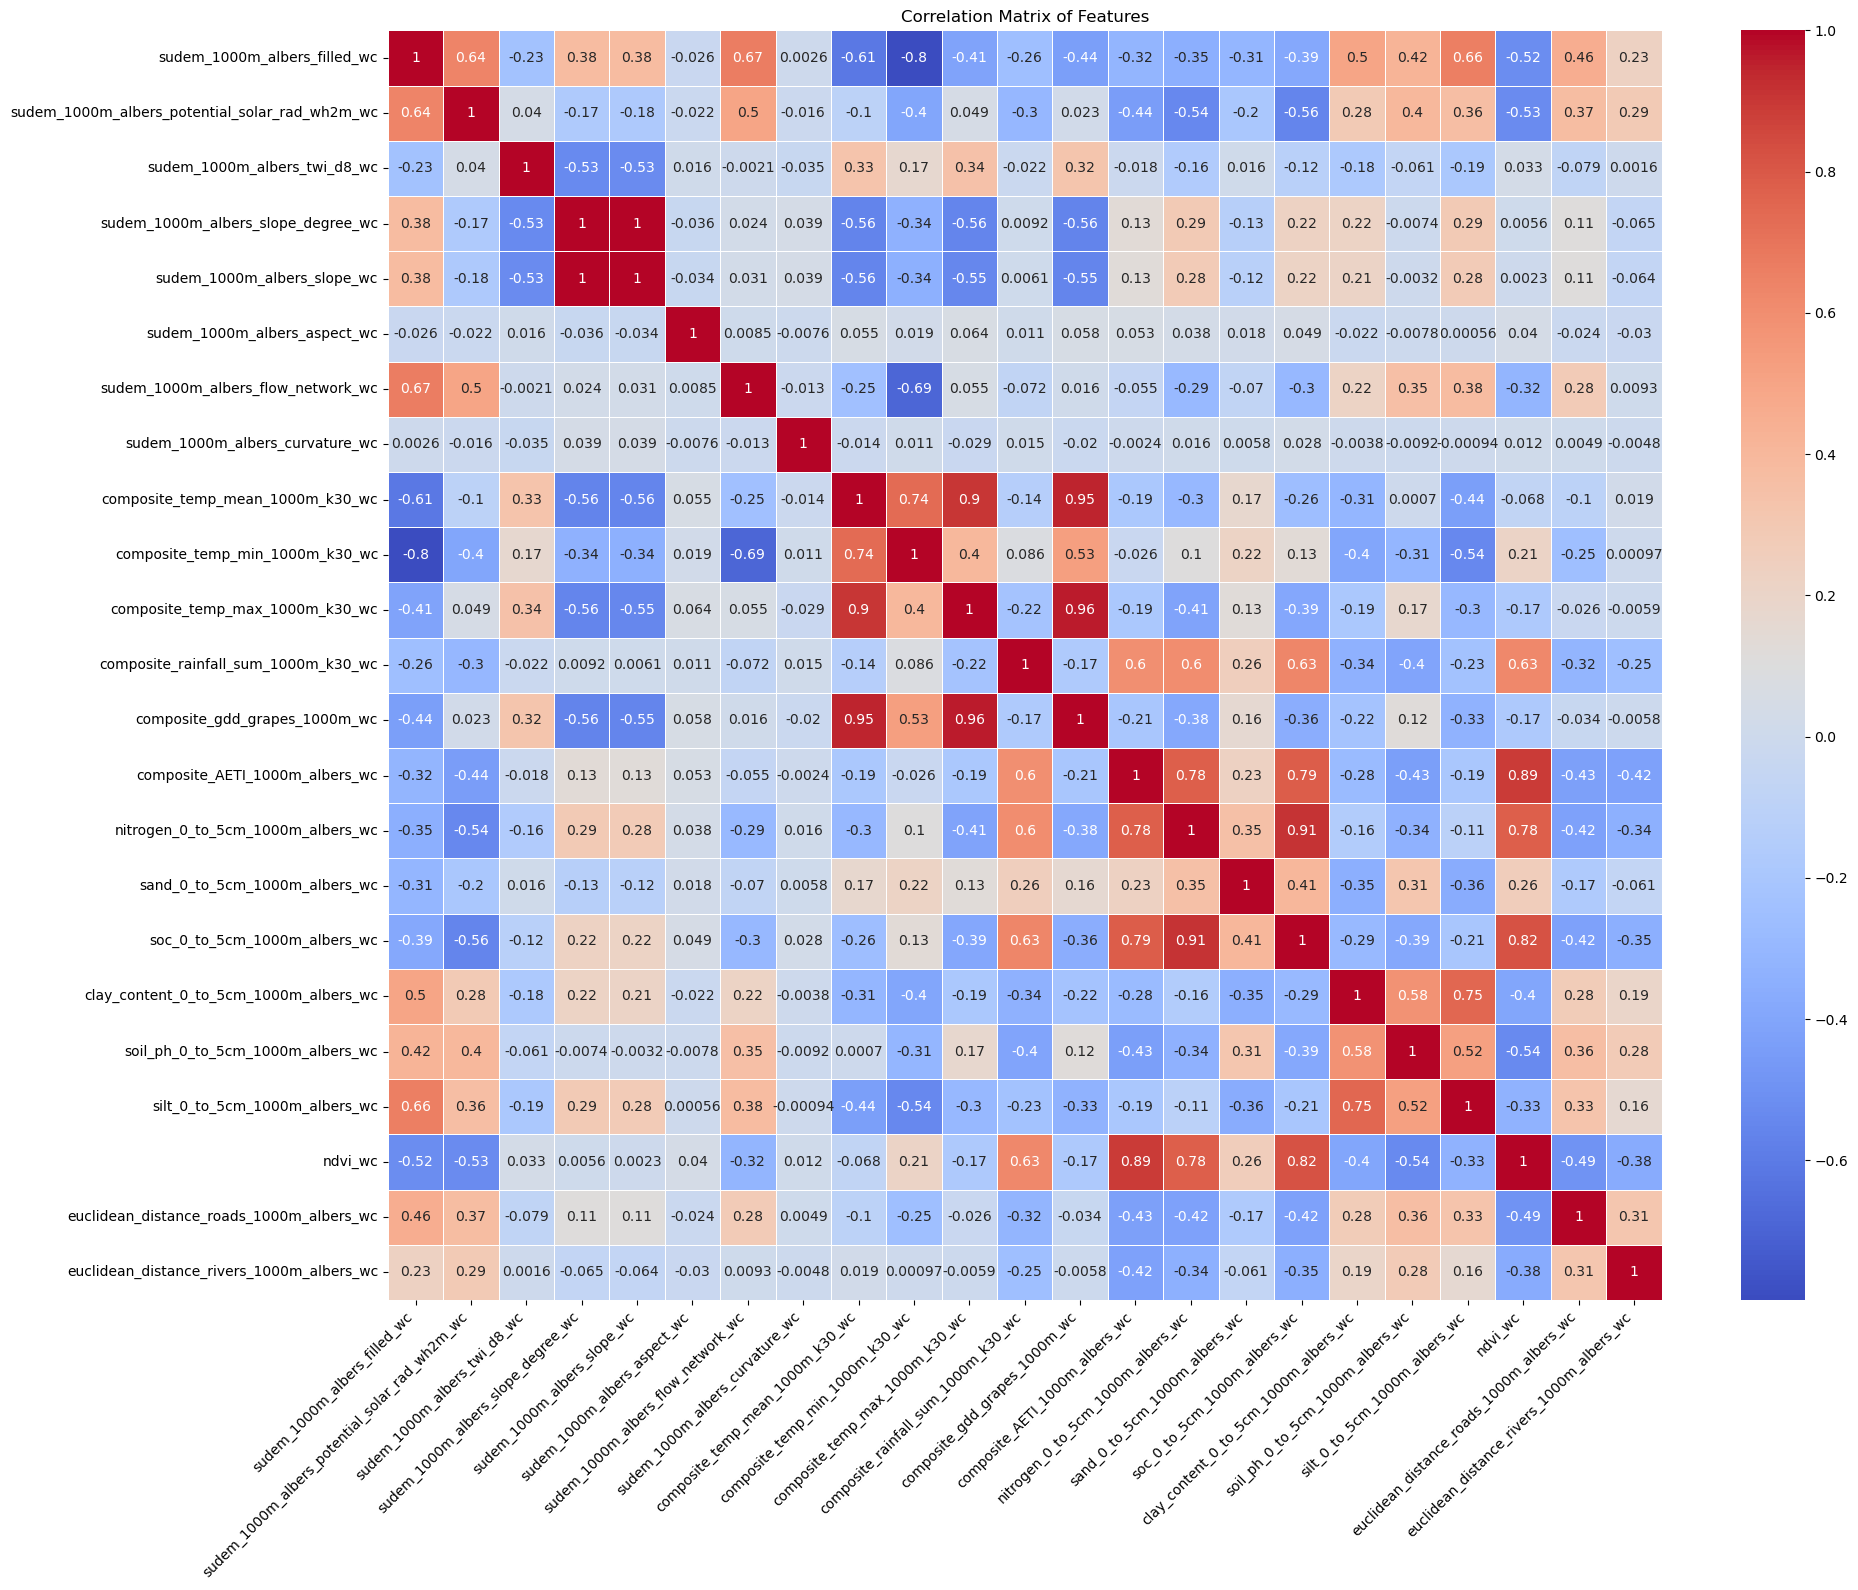

In [18]:
# Correlation matrix of features

# drop OID__, POINT_X, POINT_Y, suitability columns 
columns_to_drop = ['suitability', 'OID_', 'POINT_X', 'POINT_Y'] 
features = combined_df.drop(columns=columns_to_drop)

plt.figure(figsize=(20, 16))
correlation_matrix = features.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Features')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

<Figure size 1500x1000 with 0 Axes>

<Axes: >

<Axes: xlabel='sudem_1000m_albers_filled_wc', ylabel='Count'>

Text(0.5, 1.0, 'sudem_1000m_albers_filled_wc')

<Axes: >

...

<Axes: xlabel='sudem_1000m_albers_curvature_wc', ylabel='Count'>

Text(0.5, 1.0, 'sudem_1000m_albers_curvature_wc')

<Axes: >

<Axes: xlabel='composite_temp_mean_1000m_k30_wc', ylabel='Count'>

Text(0.5, 1.0, 'composite_temp_mean_1000m_k30_wc')

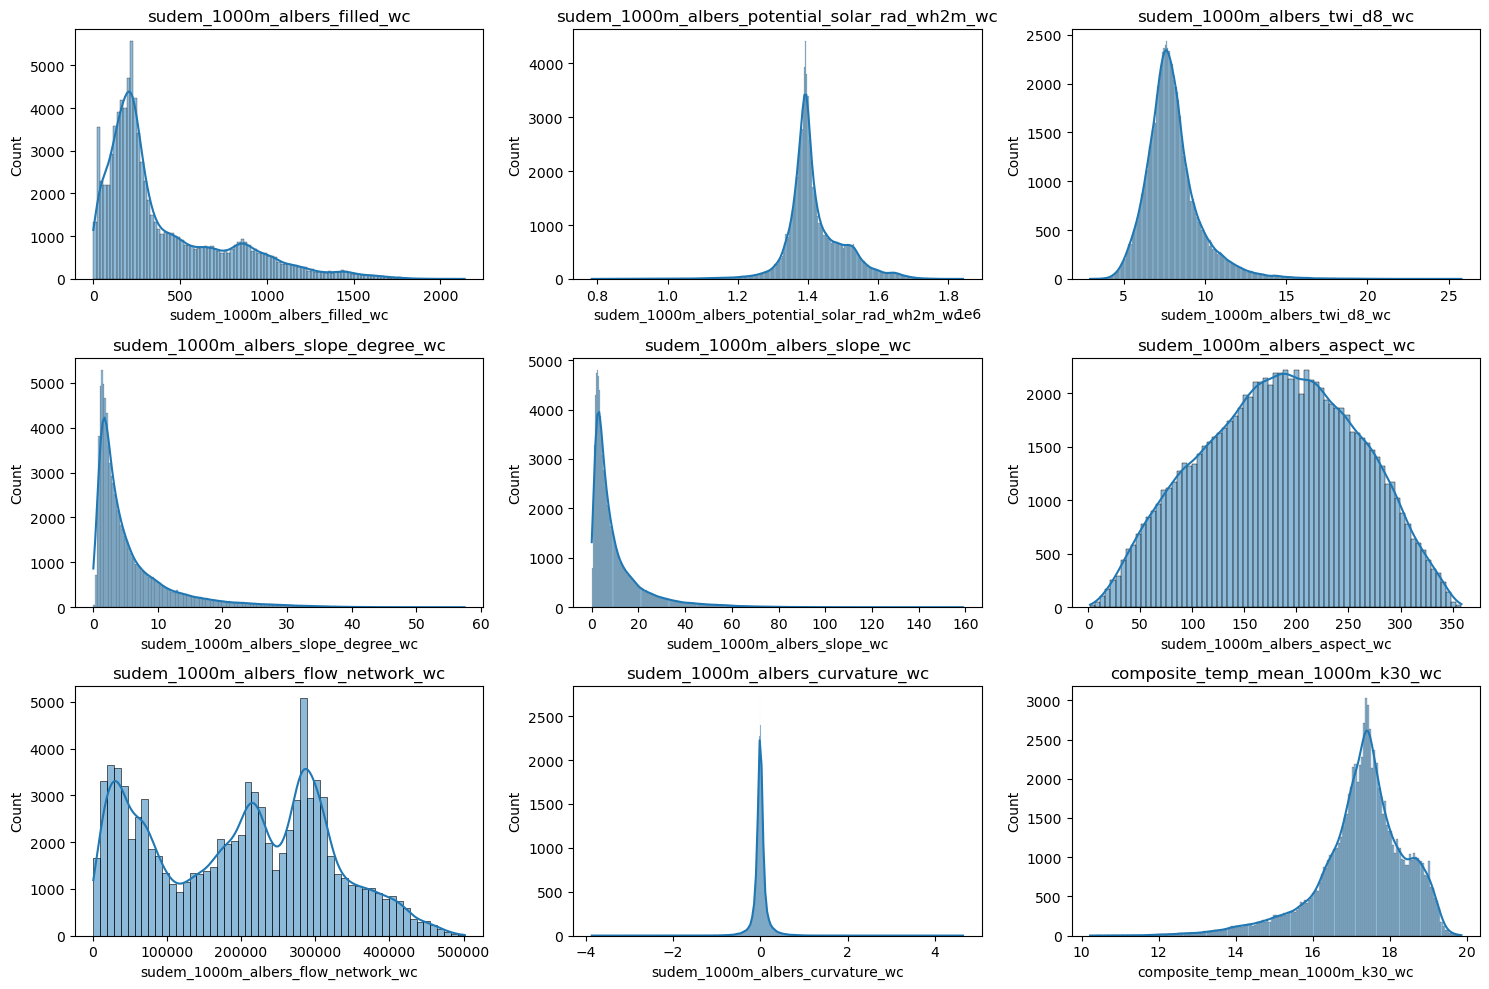

In [19]:
# Distribution of each feature
plt.figure(figsize=(15, 10))
for i, column in enumerate(combined_df.columns[3:12], 1):
    plt.subplot(3, 3, i)
    sns.histplot(combined_df[column], kde=True)
    plt.title(column)
plt.tight_layout()
plt.show()

<Figure size 1500x1000 with 0 Axes>

<Axes: >

<Axes: xlabel='composite_temp_min_1000m_k30_wc', ylabel='Count'>

Text(0.5, 1.0, 'composite_temp_min_1000m_k30_wc')

<Axes: >

...

<Axes: xlabel='soc_0_to_5cm_1000m_albers_wc', ylabel='Count'>

Text(0.5, 1.0, 'soc_0_to_5cm_1000m_albers_wc')

<Axes: >

<Axes: xlabel='clay_content_0_to_5cm_1000m_albers_wc', ylabel='Count'>

Text(0.5, 1.0, 'clay_content_0_to_5cm_1000m_albers_wc')

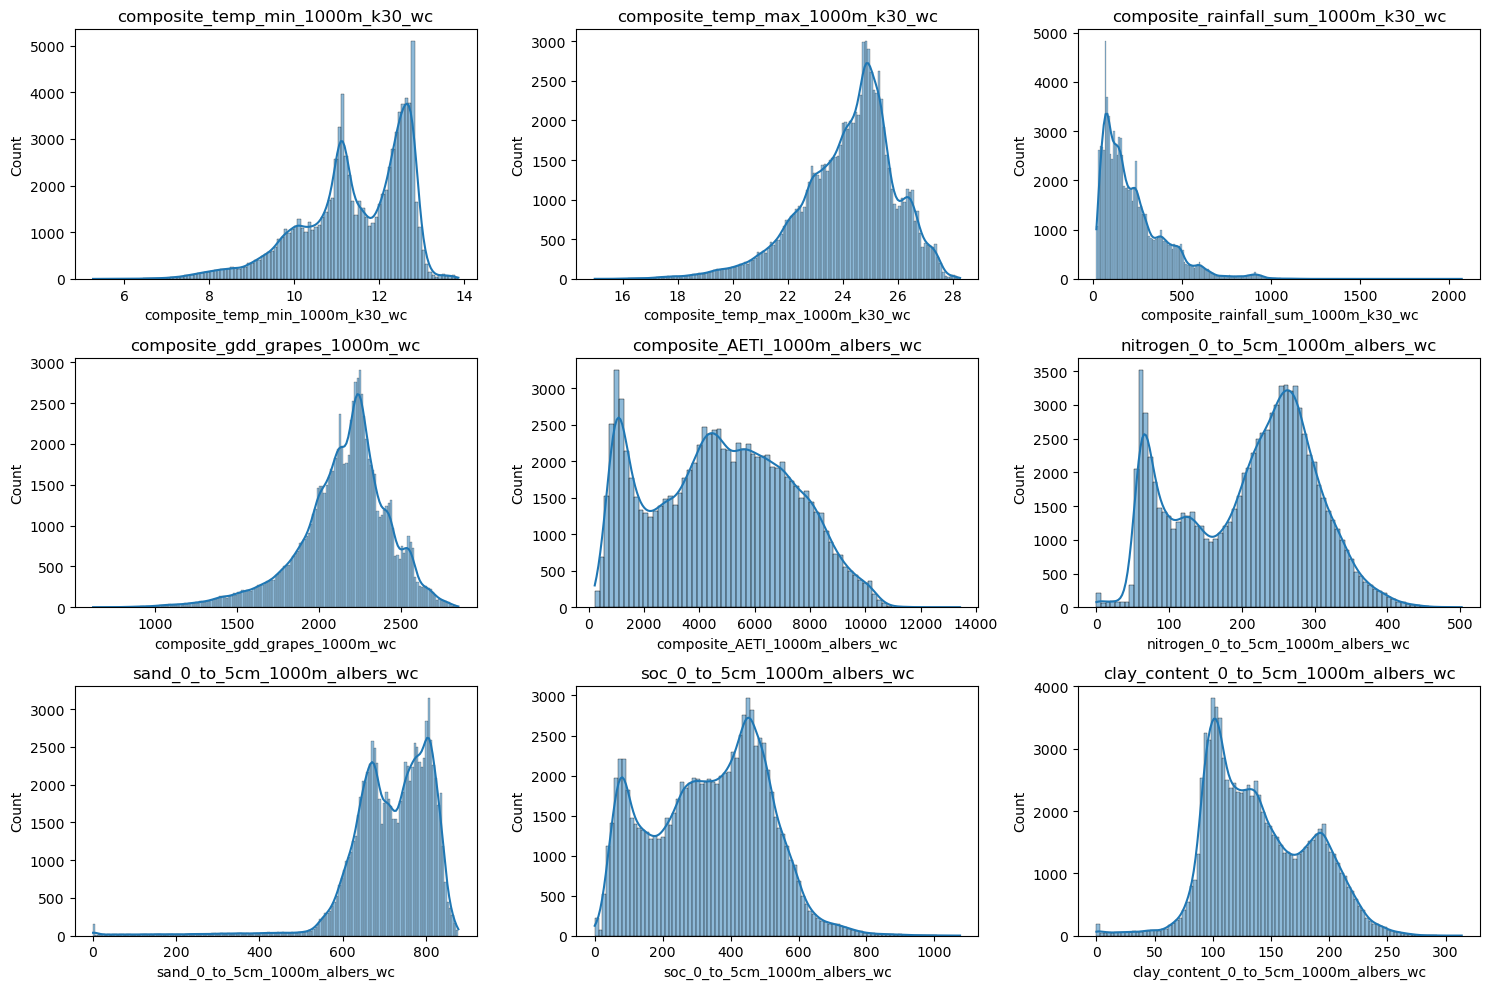

In [20]:
# Distribution of each feature
plt.figure(figsize=(15, 10))
for i, column in enumerate(combined_df.columns[12:21], 1):
    plt.subplot(3, 3, i)
    sns.histplot(combined_df[column], kde=True)
    plt.title(column)
plt.tight_layout()
plt.show()

<Figure size 1500x1000 with 0 Axes>

<Axes: >

<Axes: xlabel='soil_ph_0_to_5cm_1000m_albers_wc', ylabel='Count'>

Text(0.5, 1.0, 'soil_ph_0_to_5cm_1000m_albers_wc')

<Axes: >

...

<Axes: xlabel='euclidean_distance_rivers_1000m_albers_wc', ylabel='Count'>

Text(0.5, 1.0, 'euclidean_distance_rivers_1000m_albers_wc')

<Axes: >

<Axes: xlabel='suitability', ylabel='Count'>

Text(0.5, 1.0, 'suitability')

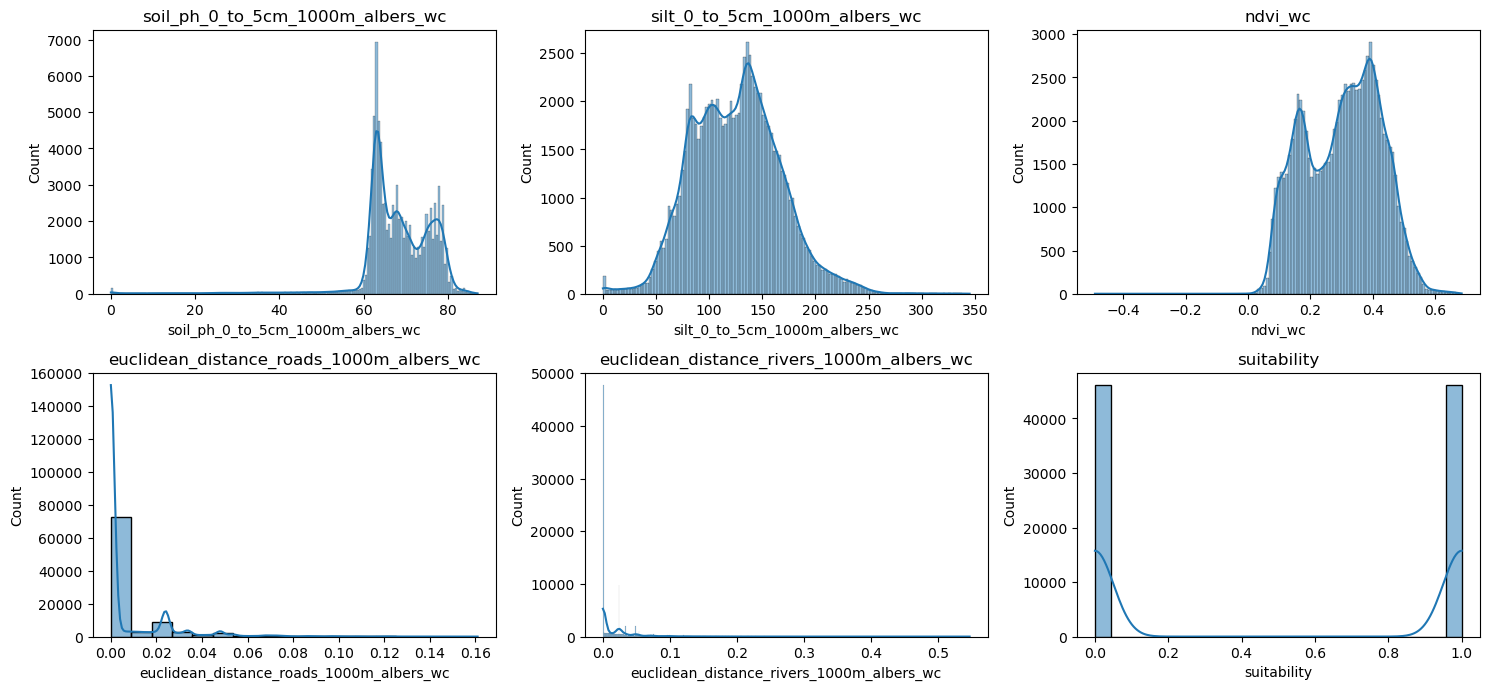

In [21]:
# Distribution of each feature
plt.figure(figsize=(15, 10))
for i, column in enumerate(combined_df.columns[21:], 1):
    plt.subplot(3, 3, i)
    sns.histplot(combined_df[column], kde=True)
    plt.title(column)
plt.tight_layout()
plt.show()

<Figure size 1200x800 with 0 Axes>

Text(0.5, 1.0, 'Geographical Distribution of Points')

Text(0.5, 0, 'Longitude')

Text(0, 0.5, 'Latitude')

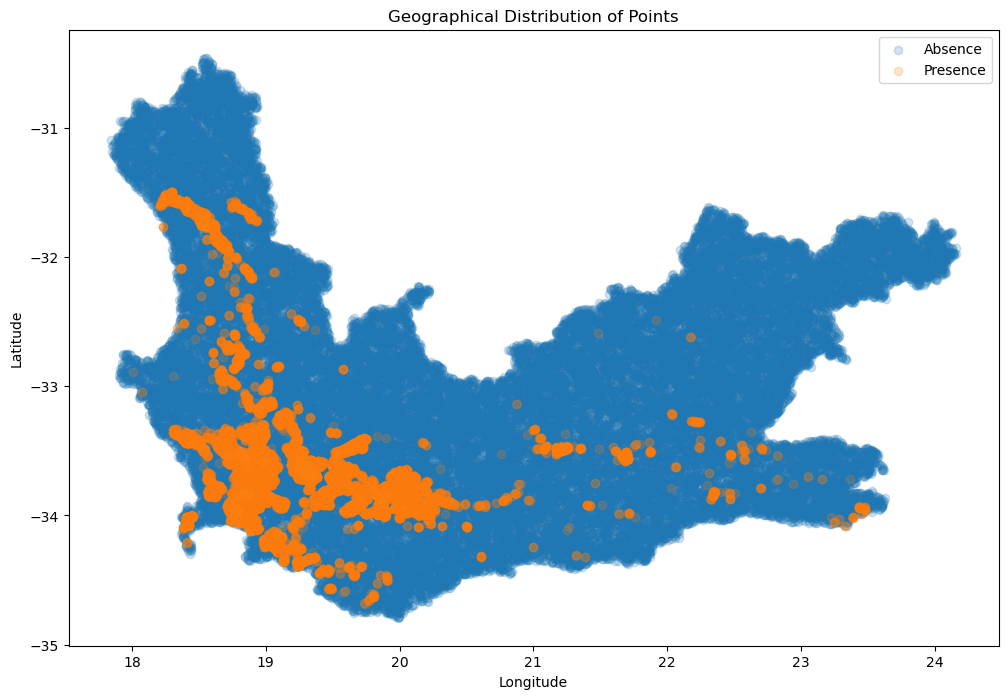

In [22]:
# Geographical distribution (if latitude and longitude are available)
plt.figure(figsize=(12, 8))
plt.scatter(combined_df[combined_df['suitability'] == 0]['POINT_X'], 
            combined_df[combined_df['suitability'] == 0]['POINT_Y'], 
            alpha=0.2, label='Absence')
plt.scatter(combined_df[combined_df['suitability'] == 1]['POINT_X'], 
            combined_df[combined_df['suitability'] == 1]['POINT_Y'], 
            alpha=0.2, label='Presence')
plt.title('Geographical Distribution of Points')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.show()

## Model training

In [23]:
# I can potentially look at normalizing the data see the example below

# from sklearn.preprocessing import StandardScaler

# Normalizing 
# No need to normalize binary or Likert Scaled columns. 

# columns_to_normalize = df.columns[1:5] 

# Initialize the StandardScaler

# scaler = StandardScaler()

# Fit and transform the selected columns

# df[columns_to_normalize] = scaler.fit_transform(df[columns_to_normalize])

In [24]:
# columns to drop
# I am dropping the suitability column because it is the target variable and OID column because it is an identifier and to reduce overfitting and noise 
# I can potentially drop the geometry columns as well?? 
# We can potentially drop POINT_X and POINT_Y because they are location identifiers rather than predictive features
# But if geographical location is important we can potentially keep them

# columns_to_drop = ['suitability', 'OID_', 'POINT_X', 'POINT_Y'] 

# features/ predictor variables
X = combined_df.drop(columns=columns_to_drop)

# target variable (0 and 1)
y = combined_df['suitability']




In [25]:
# Create a train/test split with 20% as test size
# random_state controls the shuffling applied to the data before applying the split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

In [26]:

# Initialize the XGBoost regressor
# There is also a XGBClassifier 
#  The XGBRegressor class in the XGBoost Python API is used for regression problems 

xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42)

# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred = xgb_model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
# accuracy = accuracy_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared Score: {r2:.4f}")

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

Mean Absolute Error: 0.0752
Mean Squared Error: 0.0286
R-squared Score: 0.8857


## Feature importance

In [27]:
# Get feature importance
feature_importance = xgb_model.feature_importances_
feature_names = X.columns

In [28]:
# Sort features by importance
sorted_idx = np.argsort(feature_importance)
sorted_features = feature_names[sorted_idx]
sorted_features

Index(['sudem_1000m_albers_curvature_wc', 'sudem_1000m_albers_aspect_wc',
       'sudem_1000m_albers_twi_d8_wc', 'nitrogen_0_to_5cm_1000m_albers_wc',
       'soc_0_to_5cm_1000m_albers_wc',
       'sudem_1000m_albers_potential_solar_rad_wh2m_wc',
       'composite_AETI_1000m_albers_wc', 'composite_temp_mean_1000m_k30_wc',
       'composite_rainfall_sum_1000m_k30_wc',
       'sudem_1000m_albers_flow_network_wc', 'composite_temp_min_1000m_k30_wc',
       'soil_ph_0_to_5cm_1000m_albers_wc', 'sudem_1000m_albers_slope_wc',
       'composite_gdd_grapes_1000m_wc', 'sudem_1000m_albers_filled_wc',
       'sand_0_to_5cm_1000m_albers_wc', 'sudem_1000m_albers_slope_degree_wc',
       'clay_content_0_to_5cm_1000m_albers_wc',
       'composite_temp_max_1000m_k30_wc',
       'euclidean_distance_rivers_1000m_albers_wc',
       'euclidean_distance_roads_1000m_albers_wc',
       'silt_0_to_5cm_1000m_albers_wc', 'ndvi_wc'],
      dtype='object')

<Figure size 1000x600 with 0 Axes>

<BarContainer object of 23 artists>

([<matplotlib.axis.YTick at 0x2d95c07e420>,
 [Text(0, 0, 'sudem_1000m_albers_curvature_wc'),
  Text(0, 1, 'sudem_1000m_albers_aspect_wc'),
  Text(0, 2, 'sudem_1000m_albers_twi_d8_wc'),
  Text(0, 3, 'nitrogen_0_to_5cm_1000m_albers_wc'),
  Text(0, 4, 'soc_0_to_5cm_1000m_albers_wc'),
  Text(0, 5, 'sudem_1000m_albers_potential_solar_rad_wh2m_wc'),
  Text(0, 6, 'composite_AETI_1000m_albers_wc'),
  Text(0, 7, 'composite_temp_mean_1000m_k30_wc'),
  Text(0, 8, 'composite_rainfall_sum_1000m_k30_wc'),
  Text(0, 9, 'sudem_1000m_albers_flow_network_wc'),
  Text(0, 10, 'composite_temp_min_1000m_k30_wc'),
  Text(0, 11, 'soil_ph_0_to_5cm_1000m_albers_wc'),
  Text(0, 12, 'sudem_1000m_albers_slope_wc'),
  Text(0, 13, 'composite_gdd_grapes_1000m_wc'),
  Text(0, 14, 'sudem_1000m_albers_filled_wc'),
  Text(0, 15, 'sand_0_to_5cm_1000m_albers_wc'),
  Text(0, 16, 'sudem_1000m_albers_slope_degree_wc'),
  Text(0, 17, 'clay_content_0_to_5cm_1000m_albers_wc'),
  Text(0, 18, 'composite_temp_max_1000m_k30_wc'),
  

Text(0.5, 0, 'Importance')

Text(0.5, 1.0, 'Feature Importance')

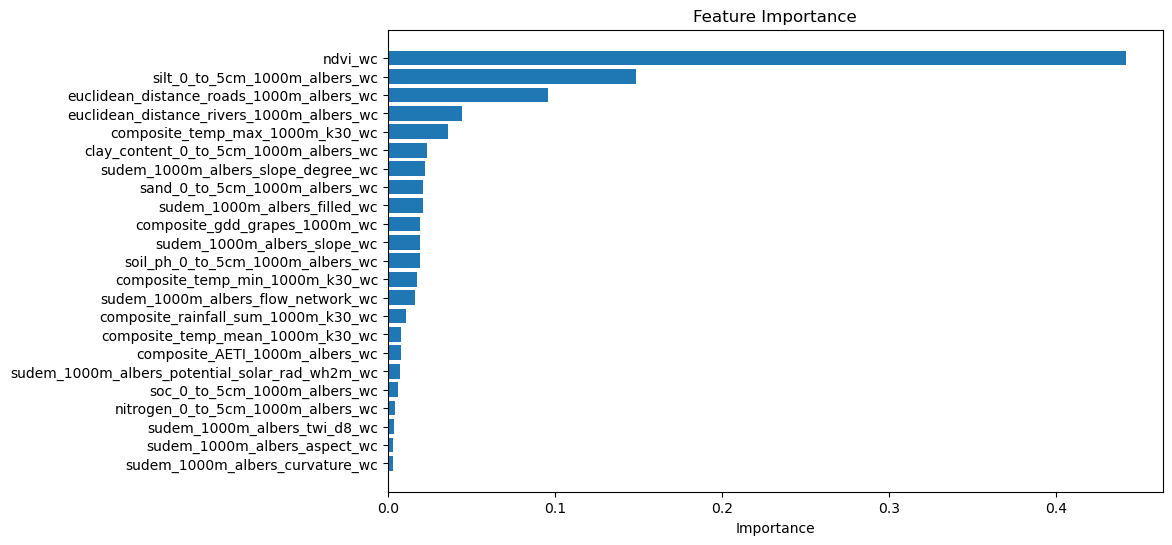

In [29]:
# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_features)), feature_importance[sorted_idx])
plt.yticks(range(len(sorted_features)), sorted_features)
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.show()

## Predicting suitability for new locations

In [30]:
new_locations_df = pd.read_csv('C:/Users/charl/Desktop/__Thesis - Research/Github/vineyard-establishment-using-xgboost/input_points_data/temp_mean_raster_to_points_wc_2.csv', delimiter=';')

print("New locations", new_locations_df.shape)

New locations (124719, 26)


In [31]:
print("New locations")
new_locations_df.head()
new_locations_df.describe()
new_locations_df.shape

New locations


,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_slope_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_k30_wc,composite_temp_min_1000m_k30_wc,composite_temp_max_1000m_k30_wc,composite_rainfall_sum_1000m_k30_wc,composite_gdd_grapes_1000m_wc,composite_AETI_1000m_albers_wc,nitrogen_0_to_5cm_1000m_albers_wc,sand_0_to_5cm_1000m_albers_wc,soc_0_to_5cm_1000m_albers_wc,clay_content_0_to_5cm_1000m_albers_wc,soil_ph_0_to_5cm_1000m_albers_wc,silt_0_to_5cm_1000m_albers_wc,ndvi_wc,euclidean_distance_roads_1000m_albers_wc,euclidean_distance_rivers_1000m_albers_wc
0,1,"17,915000000153555","-33,025000002339254","20,4533997","1373555,8750000","10,1030378","2,8192158","4,1055756","286,4891968","2764,6491699","0,2575383","17,8092937","12,7749853","23,9772301","50,2829247","2116,1140137","1381,9915771","212,2704010","807,1864014","506,6420288","111,2053680","70,1265869","81,6082001","0,3210027","0,0000000","0,2519100"
1,2,"17,925000000153318","-33,025000002339254","22,9881496","1371818,8750000","9,9369183","3,0779545","4,0687332","234,9720917",NaN,NaN,"17,8084679","12,7611475","23,9920540","51,6015205","2117,1230469","1681,8825684","238,9432678","807,2391357","526,4843140","116,8121109","69,8861084","75,9487457","0,3291732","0,0000000","0,2518362"
2,3,"17,935000000153138","-33,025000002339254",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"17,8057690","12,7534132","23,9939995",NaN,"2116,2209473",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,"17,945000000152731","-33,025000002339254",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"17,8166637","12,7526712","24,0171661",NaN,"2118,6562500",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,"17,955000000152552","-33,025000002339254",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"17,8099804",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,OID_
count,124719.000000
mean,62360.000000
std,36003.418449
min,1.000000
25%,31180.500000
50%,62360.000000
75%,93539.500000
max,124719.000000


(124719, 26)

In [32]:
new_locations_df.isnull().sum()

OID_                                                 0
POINT_X                                              0
POINT_Y                                              0
sudem_1000m_albers_filled_wc                      1759
sudem_1000m_albers_potential_solar_rad_wh2m_wc    1771
sudem_1000m_albers_twi_d8_wc                      1773
sudem_1000m_albers_slope_degree_wc                1773
sudem_1000m_albers_slope_wc                       1773
sudem_1000m_albers_aspect_wc                      1768
sudem_1000m_albers_flow_network_wc                1803
sudem_1000m_albers_curvature_wc                   1803
composite_temp_mean_1000m_k30_wc                     0
composite_temp_min_1000m_k30_wc                   2053
composite_temp_max_1000m_k30_wc                   2053
composite_rainfall_sum_1000m_k30_wc               1911
composite_gdd_grapes_1000m_wc                     2053
composite_AETI_1000m_albers_wc                    1813
nitrogen_0_to_5cm_1000m_albers_wc                 1850
sand_0_to_

In [33]:
new_locations_df.dtypes

OID_                                               int64
POINT_X                                           object
POINT_Y                                           object
sudem_1000m_albers_filled_wc                      object
sudem_1000m_albers_potential_solar_rad_wh2m_wc    object
sudem_1000m_albers_twi_d8_wc                      object
sudem_1000m_albers_slope_degree_wc                object
sudem_1000m_albers_slope_wc                       object
sudem_1000m_albers_aspect_wc                      object
sudem_1000m_albers_flow_network_wc                object
sudem_1000m_albers_curvature_wc                   object
composite_temp_mean_1000m_k30_wc                  object
composite_temp_min_1000m_k30_wc                   object
composite_temp_max_1000m_k30_wc                   object
composite_rainfall_sum_1000m_k30_wc               object
composite_gdd_grapes_1000m_wc                     object
composite_AETI_1000m_albers_wc                    object
nitrogen_0_to_5cm_1000m_albers_

In [34]:
# Should not be necessary if i label my columns correctly from the start
new_locations_df.rename(columns={'composite_temp_mean_1000m_k30': 'composite_temp_mean_1000m_k30_wc'}, inplace=True)

In [35]:
# Converting the columns to float
columns_to_convert_for_new_locations = ['POINT_X','POINT_Y','sudem_1000m_albers_filled_wc', 'sudem_1000m_albers_potential_solar_rad_wh2m_wc',
                        'sudem_1000m_albers_twi_d8_wc', 'sudem_1000m_albers_slope_degree_wc', 'sudem_1000m_albers_slope_wc',
                        'sudem_1000m_albers_aspect_wc', 'sudem_1000m_albers_flow_network_wc', 'sudem_1000m_albers_curvature_wc',
                        'composite_temp_mean_1000m_k30_wc','composite_temp_min_1000m_k30_wc', 'composite_temp_max_1000m_k30_wc',
                        'composite_rainfall_sum_1000m_k30_wc', 'composite_gdd_grapes_1000m_wc', 'composite_AETI_1000m_albers_wc',
                        'nitrogen_0_to_5cm_1000m_albers_wc', 'sand_0_to_5cm_1000m_albers_wc', 'soc_0_to_5cm_1000m_albers_wc',
                        'clay_content_0_to_5cm_1000m_albers_wc', 'soil_ph_0_to_5cm_1000m_albers_wc', 'silt_0_to_5cm_1000m_albers_wc',
                        'ndvi_wc', 'euclidean_distance_roads_1000m_albers_wc', 'euclidean_distance_rivers_1000m_albers_wc']

for col in columns_to_convert_for_new_locations:
    new_locations_df[col] = clean_and_convert(new_locations_df[col])

In [36]:
# checking the data types again

new_locations_df.dtypes

OID_                                                int64
POINT_X                                           float64
POINT_Y                                           float64
sudem_1000m_albers_filled_wc                      float64
sudem_1000m_albers_potential_solar_rad_wh2m_wc    float64
sudem_1000m_albers_twi_d8_wc                      float64
sudem_1000m_albers_slope_degree_wc                float64
sudem_1000m_albers_slope_wc                       float64
sudem_1000m_albers_aspect_wc                      float64
sudem_1000m_albers_flow_network_wc                float64
sudem_1000m_albers_curvature_wc                   float64
composite_temp_mean_1000m_k30_wc                  float64
composite_temp_min_1000m_k30_wc                   float64
composite_temp_max_1000m_k30_wc                   float64
composite_rainfall_sum_1000m_k30_wc               float64
composite_gdd_grapes_1000m_wc                     float64
composite_AETI_1000m_albers_wc                    float64
nitrogen_0_to_

In [37]:
new_locations_df

# creating a new df called new_locations_df_2 to use for the csv file
new_locations_df_2 = new_locations_df.copy()

new_locations_df_2

,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_slope_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_k30_wc,composite_temp_min_1000m_k30_wc,composite_temp_max_1000m_k30_wc,composite_rainfall_sum_1000m_k30_wc,composite_gdd_grapes_1000m_wc,composite_AETI_1000m_albers_wc,nitrogen_0_to_5cm_1000m_albers_wc,sand_0_to_5cm_1000m_albers_wc,soc_0_to_5cm_1000m_albers_wc,clay_content_0_to_5cm_1000m_albers_wc,soil_ph_0_to_5cm_1000m_albers_wc,silt_0_to_5cm_1000m_albers_wc,ndvi_wc,euclidean_distance_roads_1000m_albers_wc,euclidean_distance_rivers_1000m_albers_wc
0,1,17.915,-33.025,20.453400,1373555.875,10.103038,2.819216,4.105576,286.489197,2764.649170,0.257538,17.809294,12.774985,23.977230,50.282925,2116.114014,1381.991577,212.270401,807.186401,506.642029,111.205368,70.126587,81.608200,0.321003,0.000000,0.251910
1,2,17.925,-33.025,22.988150,1371818.875,9.936918,3.077955,4.068733,234.972092,NaN,NaN,17.808468,12.761147,23.992054,51.601520,2117.123047,1681.882568,238.943268,807.239136,526.484314,116.812111,69.886108,75.948746,0.329173,0.000000,0.251836
2,3,17.935,-33.025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.805769,12.753413,23.994000,NaN,2116.220947,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,17.945,-33.025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.816664,12.752671,24.017166,NaN,2118.656250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,17.955,-33.025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.809980,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124714,124715,18.905,-31.205,235.445831,1455278.125,7.529870,0.983524,1.702672,126.227562,151146.828125,0.029424,19.273752,12.657167,27.431025,75.350937,2565.647949,421.781220,87.539291,766.102661,77.685387,127.769173,80.877304,106.148918,0.124193,0.017241,0.113241
124715,124716,18.915,-31.205,240.846207,1458313.625,8.765619,1.327325,2.316294,244.274383,152032.968750,0.020197,19.279291,12.648899,27.452206,76.413811,2568.863525,385.502716,93.970314,771.912781,89.703964,115.422607,80.000000,112.692329,0.123818,0.024000,0.120000
124716,124717,18.925,-31.205,253.748779,1455725.750,8.161468,2.315781,3.997422,246.881912,153107.390625,0.032221,19.285227,12.640968,27.473740,77.395081,2572.175293,402.074585,95.339104,772.395019,89.363007,116.934731,79.834351,110.089333,0.118804,0.024000,0.120000
124717,124718,18.935,-31.205,271.048920,1466811.750,7.805713,1.089777,1.902314,198.175827,155263.437500,-0.003584,19.249308,12.611215,27.426840,78.280823,2564.882812,514.475281,97.600769,767.642334,92.682198,122.150635,79.033150,110.731911,0.114487,0.042787,0.133379


,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_slope_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_k30_wc,composite_temp_min_1000m_k30_wc,composite_temp_max_1000m_k30_wc,composite_rainfall_sum_1000m_k30_wc,composite_gdd_grapes_1000m_wc,composite_AETI_1000m_albers_wc,nitrogen_0_to_5cm_1000m_albers_wc,sand_0_to_5cm_1000m_albers_wc,soc_0_to_5cm_1000m_albers_wc,clay_content_0_to_5cm_1000m_albers_wc,soil_ph_0_to_5cm_1000m_albers_wc,silt_0_to_5cm_1000m_albers_wc,ndvi_wc,euclidean_distance_roads_1000m_albers_wc,euclidean_distance_rivers_1000m_albers_wc
0,1,17.915,-33.025,20.453400,1373555.875,10.103038,2.819216,4.105576,286.489197,2764.649170,0.257538,17.809294,12.774985,23.977230,50.282925,2116.114014,1381.991577,212.270401,807.186401,506.642029,111.205368,70.126587,81.608200,0.321003,0.000000,0.251910
1,2,17.925,-33.025,22.988150,1371818.875,9.936918,3.077955,4.068733,234.972092,NaN,NaN,17.808468,12.761147,23.992054,51.601520,2117.123047,1681.882568,238.943268,807.239136,526.484314,116.812111,69.886108,75.948746,0.329173,0.000000,0.251836
2,3,17.935,-33.025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.805769,12.753413,23.994000,NaN,2116.220947,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,17.945,-33.025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.816664,12.752671,24.017166,NaN,2118.656250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,17.955,-33.025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.809980,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124714,124715,18.905,-31.205,235.445831,1455278.125,7.529870,0.983524,1.702672,126.227562,151146.828125,0.029424,19.273752,12.657167,27.431025,75.350937,2565.647949,421.781220,87.539291,766.102661,77.685387,127.769173,80.877304,106.148918,0.124193,0.017241,0.113241
124715,124716,18.915,-31.205,240.846207,1458313.625,8.765619,1.327325,2.316294,244.274383,152032.968750,0.020197,19.279291,12.648899,27.452206,76.413811,2568.863525,385.502716,93.970314,771.912781,89.703964,115.422607,80.000000,112.692329,0.123818,0.024000,0.120000
124716,124717,18.925,-31.205,253.748779,1455725.750,8.161468,2.315781,3.997422,246.881912,153107.390625,0.032221,19.285227,12.640968,27.473740,77.395081,2572.175293,402.074585,95.339104,772.395019,89.363007,116.934731,79.834351,110.089333,0.118804,0.024000,0.120000
124717,124718,18.935,-31.205,271.048920,1466811.750,7.805713,1.089777,1.902314,198.175827,155263.437500,-0.003584,19.249308,12.611215,27.426840,78.280823,2564.882812,514.475281,97.600769,767.642334,92.682198,122.150635,79.033150,110.731911,0.114487,0.042787,0.133379


In [38]:
# interpolate the columns with null values

columns_to_interpolate_for_new_locations = ['sudem_1000m_albers_filled_wc', 'sudem_1000m_albers_potential_solar_rad_wh2m_wc',
                                            'sudem_1000m_albers_twi_d8_wc', 'sudem_1000m_albers_slope_degree_wc', 'sudem_1000m_albers_slope_wc',
                                            'sudem_1000m_albers_aspect_wc', 'sudem_1000m_albers_flow_network_wc', 'sudem_1000m_albers_curvature_wc',
                                            'composite_temp_min_1000m_k30_wc', 'composite_temp_max_1000m_k30_wc',
                                            'composite_rainfall_sum_1000m_k30_wc', 'composite_gdd_grapes_1000m_wc', 'composite_AETI_1000m_albers_wc',
                                            'nitrogen_0_to_5cm_1000m_albers_wc', 'sand_0_to_5cm_1000m_albers_wc', 'soc_0_to_5cm_1000m_albers_wc',
                                            'clay_content_0_to_5cm_1000m_albers_wc', 'soil_ph_0_to_5cm_1000m_albers_wc', 'silt_0_to_5cm_1000m_albers_wc',
                                            'ndvi_wc', 'euclidean_distance_roads_1000m_albers_wc', 'euclidean_distance_rivers_1000m_albers_wc']

interpolate_columns(new_locations_df, columns_to_interpolate_for_new_locations)

,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_slope_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_k30_wc,composite_temp_min_1000m_k30_wc,composite_temp_max_1000m_k30_wc,composite_rainfall_sum_1000m_k30_wc,composite_gdd_grapes_1000m_wc,composite_AETI_1000m_albers_wc,nitrogen_0_to_5cm_1000m_albers_wc,sand_0_to_5cm_1000m_albers_wc,soc_0_to_5cm_1000m_albers_wc,clay_content_0_to_5cm_1000m_albers_wc,soil_ph_0_to_5cm_1000m_albers_wc,silt_0_to_5cm_1000m_albers_wc,ndvi_wc,euclidean_distance_roads_1000m_albers_wc,euclidean_distance_rivers_1000m_albers_wc
0,1,17.915,-33.025,20.453400,1373555.875,10.103038,2.819216,4.105576,286.489197,2764.649170,0.257538,17.809294,12.774985,23.977230,50.282925,2116.114014,1381.991577,212.270401,807.186401,506.642029,111.205368,70.126587,81.608200,0.321003,0.000000,0.251910
1,2,17.925,-33.025,22.988150,1371818.875,9.936918,3.077955,4.068733,234.972092,2639.114319,0.199624,17.808468,12.761147,23.992054,51.601520,2117.123047,1681.882568,238.943268,807.239136,526.484314,116.812111,69.886108,75.948746,0.329173,0.000000,0.251836
2,3,17.935,-33.025,21.227237,1372884.175,9.351679,2.838572,3.884524,230.550235,2513.579468,0.141710,17.805769,12.753413,23.994000,55.607066,2116.220947,1676.782251,233.950317,809.079761,509.574896,117.445847,70.108887,73.407979,0.310696,0.000000,0.247213
3,4,17.945,-33.025,19.466323,1373949.475,8.766440,2.599189,3.700314,226.128378,2388.044617,0.083796,17.816664,12.752671,24.017166,59.612612,2118.656250,1671.681934,228.957367,810.920386,492.665479,118.079582,70.331665,70.867212,0.292220,0.000000,0.242590
4,5,17.955,-33.025,17.705410,1375014.775,8.181200,2.359806,3.516104,221.706522,2262.509766,0.025882,17.809980,12.655433,23.938325,63.618158,2100.266357,1666.581616,223.964416,812.761011,475.756061,118.713318,70.554443,68.326445,0.273743,0.000000,0.237967
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124714,124715,18.905,-31.205,235.445831,1455278.125,7.529870,0.983524,1.702672,126.227562,151146.828125,0.029424,19.273752,12.657167,27.431025,75.350937,2565.647949,421.781220,87.539291,766.102661,77.685387,127.769173,80.877304,106.148918,0.124193,0.017241,0.113241
124715,124716,18.915,-31.205,240.846207,1458313.625,8.765619,1.327325,2.316294,244.274383,152032.968750,0.020197,19.279291,12.648899,27.452206,76.413811,2568.863525,385.502716,93.970314,771.912781,89.703964,115.422607,80.000000,112.692329,0.123818,0.024000,0.120000
124716,124717,18.925,-31.205,253.748779,1455725.750,8.161468,2.315781,3.997422,246.881912,153107.390625,0.032221,19.285227,12.640968,27.473740,77.395081,2572.175293,402.074585,95.339104,772.395019,89.363007,116.934731,79.834351,110.089333,0.118804,0.024000,0.120000
124717,124718,18.935,-31.205,271.048920,1466811.750,7.805713,1.089777,1.902314,198.175827,155263.437500,-0.003584,19.249308,12.611215,27.426840,78.280823,2564.882812,514.475281,97.600769,767.642334,92.682198,122.150635,79.033150,110.731911,0.114487,0.042787,0.133379


In [39]:
new_locations_df.isnull().sum()
new_locations_df.shape

OID_                                              0
POINT_X                                           0
POINT_Y                                           0
sudem_1000m_albers_filled_wc                      0
sudem_1000m_albers_potential_solar_rad_wh2m_wc    0
sudem_1000m_albers_twi_d8_wc                      0
sudem_1000m_albers_slope_degree_wc                0
sudem_1000m_albers_slope_wc                       0
sudem_1000m_albers_aspect_wc                      0
sudem_1000m_albers_flow_network_wc                0
sudem_1000m_albers_curvature_wc                   0
composite_temp_mean_1000m_k30_wc                  0
composite_temp_min_1000m_k30_wc                   0
composite_temp_max_1000m_k30_wc                   0
composite_rainfall_sum_1000m_k30_wc               0
composite_gdd_grapes_1000m_wc                     0
composite_AETI_1000m_albers_wc                    0
nitrogen_0_to_5cm_1000m_albers_wc                 0
sand_0_to_5cm_1000m_albers_wc                     0
soc_0_to_5cm

(124719, 26)

In [40]:
original_point_x = new_locations_df['POINT_X']
original_point_y = new_locations_df['POINT_Y']

In [41]:
# Make predictions
columns_to_drop_2 = ['OID_', 'POINT_X', 'POINT_Y']

new_locations_df.drop(columns=columns_to_drop_2, inplace=True)
suitability_scores = xgb_model.predict(new_locations_df)

In [42]:
# Add predictions to the new_locations dataframe
new_locations_df['suitability_score'] = suitability_scores

# Might need to rearrange the columns according to point_x and point_y 

# Add POINT_X and POINT_Y columns back to the dataframe
new_locations_df['POINT_X'] = original_point_x
new_locations_df['POINT_Y'] = original_point_y

In [45]:
# Save results
# If i can save it with point_x and point_y that would be great
new_locations_df.to_csv('../output_points_data/wc_predicted_suitability.csv', index=False)

In [46]:
wc_predicted_suitability = pd.read_csv('C:/Users/charl/Desktop/__Thesis - Research/Github/vineyard-establishment-using-xgboost/output_points_data/wc_predicted_suitability.csv')        

In [47]:
wc_predicted_suitability.head()
wc_predicted_suitability['suitability_score'].describe()

,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_slope_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_k30_wc,composite_temp_min_1000m_k30_wc,composite_temp_max_1000m_k30_wc,composite_rainfall_sum_1000m_k30_wc,composite_gdd_grapes_1000m_wc,composite_AETI_1000m_albers_wc,nitrogen_0_to_5cm_1000m_albers_wc,sand_0_to_5cm_1000m_albers_wc,soc_0_to_5cm_1000m_albers_wc,clay_content_0_to_5cm_1000m_albers_wc,soil_ph_0_to_5cm_1000m_albers_wc,silt_0_to_5cm_1000m_albers_wc,ndvi_wc,euclidean_distance_roads_1000m_albers_wc,euclidean_distance_rivers_1000m_albers_wc,suitability_score,POINT_X,POINT_Y
0,20.453400,1373555.875,10.103038,2.819216,4.105576,286.489197,2764.649170,0.257538,17.809294,12.774985,23.977230,50.282925,2116.114014,1381.991577,212.270401,807.186401,506.642029,111.205368,70.126587,81.608200,0.321003,0.0,0.251910,-0.028977,17.915,-33.025
1,22.988150,1371818.875,9.936918,3.077955,4.068733,234.972092,2639.114319,0.199624,17.808468,12.761147,23.992054,51.601520,2117.123047,1681.882568,238.943268,807.239136,526.484314,116.812111,69.886108,75.948746,0.329173,0.0,0.251836,0.108284,17.925,-33.025
2,21.227237,1372884.175,9.351679,2.838572,3.884524,230.550235,2513.579468,0.141710,17.805769,12.753413,23.994000,55.607066,2116.220947,1676.782251,233.950317,809.079761,509.574896,117.445847,70.108887,73.407979,0.310696,0.0,0.247213,0.080995,17.935,-33.025
3,19.466323,1373949.475,8.766440,2.599189,3.700314,226.128378,2388.044617,0.083796,17.816664,12.752671,24.017166,59.612612,2118.656250,1671.681934,228.957367,810.920386,492.665479,118.079582,70.331665,70.867212,0.292220,0.0,0.242590,-0.107657,17.945,-33.025
4,17.705410,1375014.775,8.181200,2.359806,3.516104,221.706522,2262.509766,0.025882,17.809980,12.655433,23.938325,63.618158,2100.266357,1666.581616,223.964416,812.761011,475.756061,118.713318,70.554443,68.326445,0.273743,0.0,0.237967,0.100460,17.955,-33.025


count    124719.000000
mean          0.064132
std           0.204339
min          -0.743133
25%          -0.009653
50%           0.002820
75%           0.040665
max           1.261066
Name: suitability_score, dtype: float64

In [48]:
# wc_vineyard_locations only has the suitability score
wc_vineyard_suitability_score = wc_predicted_suitability['suitability_score']

In [49]:
wc_vineyard_suitability_score.to_csv('../output_points_data/only_vineyard_suitability_score_wc.csv', index=False)
new_locations_df_2

,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_slope_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_k30_wc,composite_temp_min_1000m_k30_wc,composite_temp_max_1000m_k30_wc,composite_rainfall_sum_1000m_k30_wc,composite_gdd_grapes_1000m_wc,composite_AETI_1000m_albers_wc,nitrogen_0_to_5cm_1000m_albers_wc,sand_0_to_5cm_1000m_albers_wc,soc_0_to_5cm_1000m_albers_wc,clay_content_0_to_5cm_1000m_albers_wc,soil_ph_0_to_5cm_1000m_albers_wc,silt_0_to_5cm_1000m_albers_wc,ndvi_wc,euclidean_distance_roads_1000m_albers_wc,euclidean_distance_rivers_1000m_albers_wc
0,1,17.915,-33.025,20.453400,1373555.875,10.103038,2.819216,4.105576,286.489197,2764.649170,0.257538,17.809294,12.774985,23.977230,50.282925,2116.114014,1381.991577,212.270401,807.186401,506.642029,111.205368,70.126587,81.608200,0.321003,0.000000,0.251910
1,2,17.925,-33.025,22.988150,1371818.875,9.936918,3.077955,4.068733,234.972092,NaN,NaN,17.808468,12.761147,23.992054,51.601520,2117.123047,1681.882568,238.943268,807.239136,526.484314,116.812111,69.886108,75.948746,0.329173,0.000000,0.251836
2,3,17.935,-33.025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.805769,12.753413,23.994000,NaN,2116.220947,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,17.945,-33.025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.816664,12.752671,24.017166,NaN,2118.656250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,17.955,-33.025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.809980,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124714,124715,18.905,-31.205,235.445831,1455278.125,7.529870,0.983524,1.702672,126.227562,151146.828125,0.029424,19.273752,12.657167,27.431025,75.350937,2565.647949,421.781220,87.539291,766.102661,77.685387,127.769173,80.877304,106.148918,0.124193,0.017241,0.113241
124715,124716,18.915,-31.205,240.846207,1458313.625,8.765619,1.327325,2.316294,244.274383,152032.968750,0.020197,19.279291,12.648899,27.452206,76.413811,2568.863525,385.502716,93.970314,771.912781,89.703964,115.422607,80.000000,112.692329,0.123818,0.024000,0.120000
124716,124717,18.925,-31.205,253.748779,1455725.750,8.161468,2.315781,3.997422,246.881912,153107.390625,0.032221,19.285227,12.640968,27.473740,77.395081,2572.175293,402.074585,95.339104,772.395019,89.363007,116.934731,79.834351,110.089333,0.118804,0.024000,0.120000
124717,124718,18.935,-31.205,271.048920,1466811.750,7.805713,1.089777,1.902314,198.175827,155263.437500,-0.003584,19.249308,12.611215,27.426840,78.280823,2564.882812,514.475281,97.600769,767.642334,92.682198,122.150635,79.033150,110.731911,0.114487,0.042787,0.133379


In [50]:
location_columns = ['POINT_X', 'POINT_Y']
merged_df = pd.concat([wc_vineyard_suitability_score, new_locations_df_2[location_columns]], axis=1)

merged_df

,suitability_score,POINT_X,POINT_Y
0,-0.028977,17.915,-33.025
1,0.108284,17.925,-33.025
2,0.080995,17.935,-33.025
3,-0.107657,17.945,-33.025
4,0.100460,17.955,-33.025
...,...,...,...
124714,0.010201,18.905,-31.205
124715,0.095739,18.915,-31.205
124716,-0.000809,18.925,-31.205
124717,0.001267,18.935,-31.205


In [51]:
merged_df.isnull().sum()

suitability_score    0
POINT_X              0
POINT_Y              0
dtype: int64

In [52]:
# Points with suitability score
merged_df

,suitability_score,POINT_X,POINT_Y
0,-0.028977,17.915,-33.025
1,0.108284,17.925,-33.025
2,0.080995,17.935,-33.025
3,-0.107657,17.945,-33.025
4,0.100460,17.955,-33.025
...,...,...,...
124714,0.010201,18.905,-31.205
124715,0.095739,18.915,-31.205
124716,-0.000809,18.925,-31.205
124717,0.001267,18.935,-31.205


In [ ]:
# After this i go into ArcPro and create a point shapefile from the csv file using the XY to point tool
# I then create a raster from the point shapefile using the raster to point tool
